# Use this notebook to visualise subsets / instantaneous data

**How to use:**
1. run the 3 cells in import and csv path. This will import the necessary packages, and find the LED file as well as the folder of csvs to be analysed. Here, you can check if the correct number of csv files are being detected.
Typically, changing the experiment name should work if you have already worked with it before. However, when working with a new experiment or using an updated csv folder/LED times csv, we need to update the paths one time in the EXPERIMENT_SET cell.

2. Next, we create the subset for the LED duration. The dataframe can be changed according to the requirements. After that, we create a similar dataframe for all the files for a random LED duration but before the LED to establish an animal baseline. the random LED duration is not needed if we are not comparing the animal against itself.
3. groupby is used extensively for plotting. This allows us to separate the different categories (day 1 uro, day 1 control ...) and then plot separate graphs.

For each plot, a **new df** is created which is a subset of the original df. This is done to ensure we do not edit the original df. After this, groupby is applied and its plotted.

The visualisations are saved to ./visualisation/<EXPERIMENT_SET>/<type_of_plot>/ csv + svg + jpg


### Imports + csv paths

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import random
import os

plt.style.use('seaborn')


/var/folders/n_/64hnj2wj2z9bjdmhv2pyfz6h0000gp/T/ipykernel_8608/3806409146.py:9: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


Change the paths in the two cells below to point to the correct LED times file, and the correct output csvs (these should be after main.ipynb)

In [2]:
# EXPERIMENT_SET = "d48"
EXPERIMENT_SET = "week_12"

if EXPERIMENT_SET == "d48":
    led_csv_path = Path("./data/output/selected_d48_videos_coords/vr03/LED_times.csv")
    dlc_csv_analysed_path = Path("./data/output/d48_selected_vr03/")

if EXPERIMENT_SET == "week_12":
    led_csv_path = Path("./data/output/week_12_coords/LED_times.csv")
    dlc_csv_analysed_path = Path("./data/output/week12_surface_led/")

In [3]:
led_csv = pd.read_csv(led_csv_path)
if led_csv.empty:
    print("LED csv is empty")
else:
    # number of unique rows in the csv column 1
    print(f"LED data found for {led_csv['name'].nunique()} csv files")

LED data found for 191 csv files


In [4]:
csv_files = list(dlc_csv_analysed_path.glob("**/*.csv"))
print(len(csv_files), "csv files found")

241 csv files found


### Setup Dataframes
we set up the LED df, as well as the random 3s before LED dataframe below. 

The metrics recorded are cumulative distance travelled, avg vel, avg acc, avg head-tail angle, minimum distance to LED (max height reached), % of frames above initial, magnitude of y travelled (from start to highest point), start to highest trajectory angle, 

The create_master_dataframe checks which columns are needed, and creates a master dataframe that is used downstream for visualisations. This is done so that we do not have to go back and create the dataframe for every new visualisation of the same experiment set data.

For creating new metrics, they have to be declared in create_master_dataframe and columns


In [5]:
### should i extract out the filters into a separate function?
### should each be a function??? or create a script containing all the functions?

In [11]:
# Functions necessary to create master dataframe
# Use the calls below to see how to use this functions

def find_consecutive_subsets(lst, n):
    """
    This function iterates through all possible subsets of length n in a list. (its inefficient but its fast and it works)
    If the subset is consecutive, it is added to a list of subsets.
    The check for consecutive is done by checking if the difference between the last and first element is n-1.
    The function returns the list of subsets.
    """
    subsets = []
    start = 0
    while start <= len(lst) - n:
        # print(start)
        subset = lst[start:start+n]
        if subset[-1] - subset[0] == n -1 : # check if the subset is (nearly) consecutive by checking if the difference between the last and first element is ___
            subsets.append([subset[0],subset[-1]])
        start += 1
    return subsets

def find_subset(df, start_frame, subset_length, debug = False):
    """
    Creates a list of valid frames before LED start frame. Invalid frames are frames where all likelihood < 0.25 or na, or jittery frames.
    Then, it finds the valid subsets of frames before LED start frame.
    Returns a random subset of length subset_length from the list of valid subsets.
    """
    # generate the valid subset of frames before LED start frame
    print("led start frame", start_frame) if debug else None
    # columns_to_check are likelihood col, jitter col. We do likelihood check first
    valid_cols = [col for col in df.columns if "likelihood" in col or "jittery" in col]
    likelihood_cols = [col for col in df.columns if "likelihood" in col]
    bef_led_df = df.loc[150:int(start_frame), valid_cols] #exclude first 5 seconds of video
    # print(bef_led_df.head(5))
    # an valid frame is any frame where all likelihood > 0.25 or not nan
    valid_frames = bef_led_df[likelihood_cols] > 0.25 
    # find rows where <=2 false values (i.e. 2 bodyparts or less likelihood < 0.25 or nan), aka 3 reliable body parts
    valid_frames = valid_frames.sum(axis=1) >= 3 # we sum true values and check whether number of true values >= 2
    valid_frames = valid_frames[valid_frames == True].index.tolist()    
    print("valid frames len", len(valid_frames)) if debug else None
    jitter_df = bef_led_df["jittery"]
    print("jittery frames", len(jitter_df[jitter_df == 1])) if debug else None
    jitter_df = jitter_df[jitter_df == 0]
    no_jitter_frames = jitter_df.index.tolist()
    valid_frames.extend(no_jitter_frames)
    valid_frames = list(sorted(set(valid_frames)))
    valid_subsets = find_consecutive_subsets(valid_frames, int(subset_length))
    return valid_subsets



def create_master_dataframe(columns, csv_files, led_csv, random_pre_led = False, debug = False):
    # create a dict with the columns as keys
    data = {f"{col}": [] for col in columns}
    for csv in csv_files:
        print(csv.name)
        led_row = led_csv[led_csv["name"].str.contains(csv.stem)]

        if led_row.empty:
            print(f"LED file not found for {csv.name}")
            continue

        df = pd.read_csv(csv)
        led_start_frame, led_end_frame = led_row["start frame"].values[0] - 1, led_row["end frame"].values[0] - 1 # -1 because of 0 indexing
        # led_x, led_y = led_row["x"].values[0], led_row["y"].values[0]


        if random_pre_led:
            subset_length = led_end_frame - led_start_frame
            print("subset length:", subset_length) if debug else None
            # find the subset of same length as led data before led data
            subsets = find_subset(df, led_start_frame, subset_length)
            print("subsets len", len(subsets)) if debug else None
            if len(subsets) == 0:
                print("no valid subset found for ", csv.name)
                continue
            print(subsets) if debug else None
            subset = random.choice(subsets)
            # print(start_frame, end_frame)
            start_frame, end_frame = subset[0], subset[-1]
        else:
            start_frame, end_frame = led_start_frame, led_end_frame   
    # print(start_frame, end_frame)
        name = csv.stem.split("_")[0]
        data["name"].append(name) if "name" in columns else None
        control_uro = 1 if "uro" in str(csv) else 0
        data["uroa_control"].append(control_uro) if "uroa_control" in columns else None
        day = csv.parent.name
        data["day"].append(int(day)) if "day" in columns else None
        dist = df.loc[start_frame:end_frame, "avg_dist_vel"].sum()
        data["dist"].append(dist) if "dist" in columns else None
        avg_vel = df.loc[start_frame:end_frame, "avg_dist_vel"].mean()
        data["vel"].append(avg_vel) if "vel" in columns else None
        avg_acc = df.loc[start_frame:end_frame, "avg_acc"].mean()
        data["acc"].append(avg_acc) if "acc" in columns else None
        avg_angle = df.loc[start_frame:end_frame, "angle"].mean()
        data["head_angle"].append(avg_angle) if "head_angle" in columns else None
        max_dist_surface = df.loc[start_frame:end_frame, "distance_surface"].max()
        data["dist_surface"].append(max_dist_surface) if "dist_surface" in columns else None

        frames_y = df.loc[start_frame:end_frame, [col for col in df.columns if "_y" in col]].mean(axis=1)
        frames_x = df.loc[start_frame:end_frame, [col for col in df.columns if "_x" in col]].mean(axis=1)
        
        y_initial, x_initial = frames_y.iloc[0], frames_x.iloc[0]
    
        count_above_y_initial = frames_y[frames_y > y_initial].count().sum()
        percent_above_y_initial = count_above_y_initial *100 / len(frames_y)
        data["y_up"].append(percent_above_y_initial) if "y_up" in columns else None
    
        # find frame where y is highest
        y_max_frame = frames_y.idxmax()
        # print(y_max_frame)
        y_mag = frames_y.loc[y_max_frame] - y_initial
        # x_mag = frames_x.loc[y_max_frame] - x_initial
        data["y_mag"].append(y_mag) if "y_mag" in columns else None
    
        # trajectory_angle is the angle between the initial and highest point of the trajectory using the x and the y axis
        y_max = frames_y.loc[y_max_frame]
        x_max = frames_x.loc[y_max_frame]
        # print( y_max, x_max, y_initial, x_initial)
        trajectory_angle = np.arctan2([y_max - y_initial], [x_max - x_initial])[0] * 180 / np.pi
        trajectory_angle = trajectory_angle if trajectory_angle > 0 else trajectory_angle + 360
        data["trajectory_angle"].append(trajectory_angle) if "trajectory_angle" in columns else None

        data["start_y_from_led"].append(df.loc[start_frame, "distance_surface"]) if "start_y_from_led" in columns else None

        # trajectory angle till end of led using frames_y and frames_x
        end_trajectory_angle = np.arctan2([frames_y.iloc[-1] - y_initial], [frames_x.iloc[-1] - x_initial])[0] * 180 / np.pi        
        end_trajectory_angle = end_trajectory_angle if end_trajectory_angle > 0 else end_trajectory_angle + 360
        data["end_trajectory_angle"].append(end_trajectory_angle) if "end_trajectory_angle" in columns else None

    
    
    
    for key, value in data.items():
        print(key, len(value))
    data_df = pd.DataFrame(data)
    print(data_df.head(5))

    return data_df


In [12]:
# These are the data points created for analysis 
columns = ['name',
 'uroa_control',
 'day',
 'dist',
 'vel',
 'acc',
 'head_angle',
 'dist_surface',
 'y_up',
 'y_mag',
 'trajectory_angle',
 'start_y_from_led',
 'end_trajectory_angle']


#### LED subset data frame 

In [13]:
led_df = create_master_dataframe(columns, csv_files, led_csv, random_pre_led = False)

101_M.csv
144_M.csv
116_T.csv
125_M.csv
LED file not found for 125_M.csv
114_T.csv
LED file not found for 114_T.csv
103_M.csv
146_M.csv
LED file not found for 146_M.csv
142_M.csv
159_M.csv
105_M.csv
126_M.csv
115_T.csv
LED file not found for 115_T.csv
120_M.csv
158_M.csv
139_M.csv
113_T.csv
104_M.csv
122_M.csv
137_M.csv
108_M.csv
150_M.csv
128_M.csv
149_M.csv
133_M.csv
155_M.csv
157_M.csv
121_T.csv
LED file not found for 121_T.csv
153_M.csv
LED file not found for 153_M.csv
129_M.csv
130_M.csv
148_M.csv
155_S.csv
157_S.csv
LED file not found for 157_S.csv
113_SU.csv
153_S.csv
LED file not found for 153_S.csv
129_S.csv
LED file not found for 129_S.csv
130_S.csv
LED file not found for 130_S.csv
148_S.csv
137_S.csv
108_S.csv
150_S.csv
128_S.csv
149_S.csv
133_S.csv
115_SU.csv
LED file not found for 115_SU.csv
126_S.csv
LED file not found for 126_S.csv
122_F.csv
158_S.csv
139_S.csv
104_S.csv
120_F.csv
144_S.csv
101_S.csv
125_S.csv
LED file not found for 125_S.csv
116_SU.csv
146_S.csv
103_S.c

#### creating random subset before LED

In [14]:
before_led_df = create_master_dataframe(columns, csv_files, led_csv, random_pre_led = True, debug = False)

101_M.csv
144_M.csv
116_T.csv
125_M.csv
LED file not found for 125_M.csv
114_T.csv
LED file not found for 114_T.csv
103_M.csv
146_M.csv
LED file not found for 146_M.csv
142_M.csv
159_M.csv
105_M.csv
126_M.csv
115_T.csv
LED file not found for 115_T.csv
120_M.csv
158_M.csv
139_M.csv
113_T.csv
104_M.csv
122_M.csv
137_M.csv
108_M.csv
150_M.csv
128_M.csv
149_M.csv
133_M.csv
155_M.csv
157_M.csv
121_T.csv
LED file not found for 121_T.csv
153_M.csv
LED file not found for 153_M.csv
129_M.csv
130_M.csv
148_M.csv
155_S.csv
157_S.csv
LED file not found for 157_S.csv
113_SU.csv
153_S.csv
LED file not found for 153_S.csv
129_S.csv
LED file not found for 129_S.csv
130_S.csv
LED file not found for 130_S.csv
148_S.csv
137_S.csv
108_S.csv
150_S.csv
128_S.csv
149_S.csv
133_S.csv
115_SU.csv
LED file not found for 115_SU.csv
126_S.csv
LED file not found for 126_S.csv
122_F.csv
158_S.csv
139_S.csv
104_S.csv
120_F.csv
144_S.csv
101_S.csv
125_S.csv
LED file not found for 125_S.csv
116_SU.csv
146_S.csv
103_S.c

### LED Distance/Vel and acceleration box plot

In [102]:
# create a dataframe with the data points for the led data
dist_vel_acc_df = led_df[["name","day", "uroa_control", "dist", "vel", "acc"]]

#save the dataframe
dist_vel_acc_save_path = f"./data/visualisation/{EXPERIMENT_SET}/LED_dist_vel_acc_hist/"
os.makedirs(dist_vel_acc_save_path, exist_ok = True)
dist_vel_acc_df.to_csv(dist_vel_acc_save_path+"dist_vel_acc_df.csv", index = False)

# group the data by uroa control and day
dist_vel_acc_df = dist_vel_acc_df.groupby(["uroa_control", "day"])
keys = list(dist_vel_acc_df.groups.keys())

# remove the day 5 data for uroa control if present (was there in week_12)
keys.remove((0, 5)) if (0, 5) in keys else None
keys.remove((1, 5)) if (1, 5) in keys else None

for key in keys:
    df = dist_vel_acc_df.get_group(key)
    print(f"{'uroa' if key[0] == 1 else 'control'} day {key[1]}: {len(df)}")

control day 1: 24
control day 2: 24
control day 3: 23
control day 4: 23
uroa day 1: 25
uroa day 2: 24
uroa day 3: 21
uroa day 4: 23


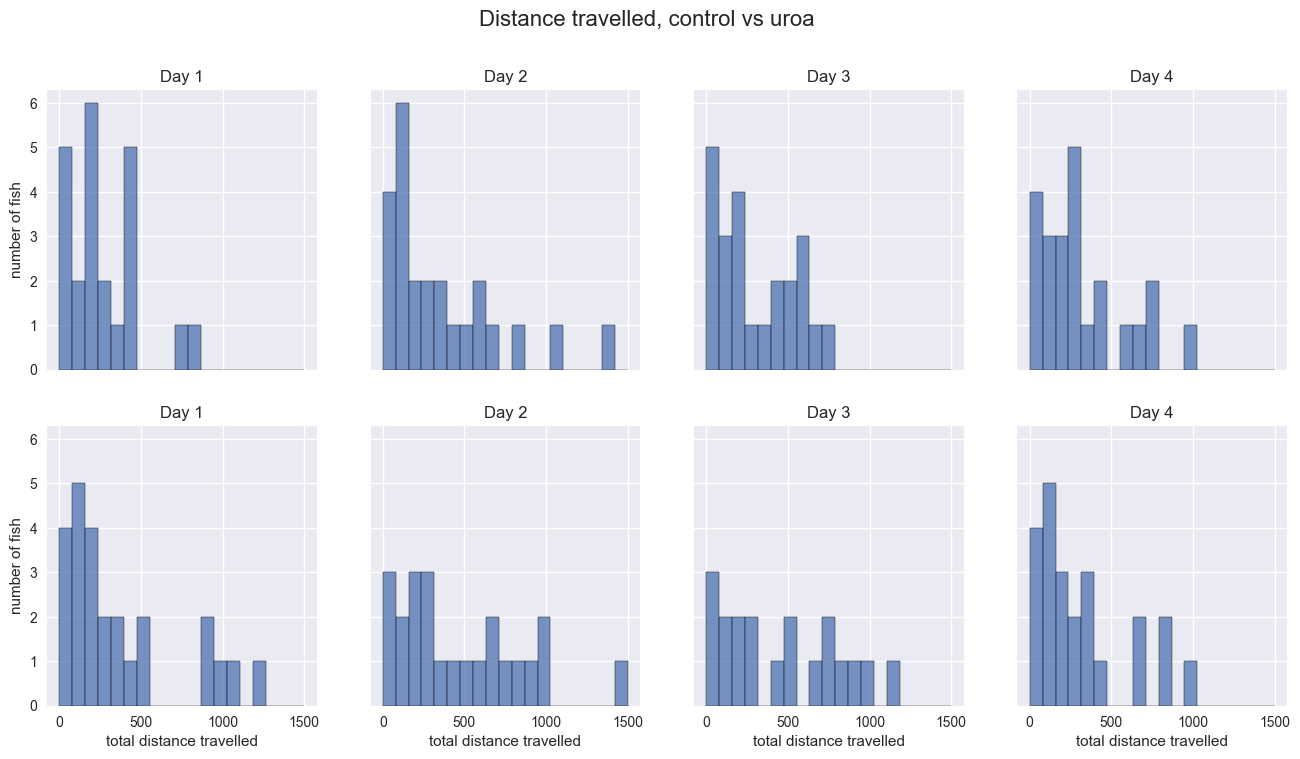

In [75]:
# for distance plots, create a 2x4 grid of plots
fig, axes = plt.subplots(2, 4, sharex=True, sharey = True, figsize=(16,8))
plt.suptitle("Distance travelled, control vs uroa", fontsize=16) 
for i, axes in enumerate(axes.flat):
    key = keys[i]
    day_df = dist_vel_acc_df.get_group(key)
    bins = np.linspace(0, 1500, 20)
    # print(day_df.head(5))
    sns.histplot(day_df["dist"],  ax=axes, bins = bins)
    axes.set_title(f"Day {key[1]}")
    axes.set_xlabel("total distance travelled")
    axes.set_ylabel("number of fish")

#save png and svg
plt.savefig(dist_vel_acc_save_path+"dist_hist.png")
plt.savefig(dist_vel_acc_save_path+"dist_hist.svg")

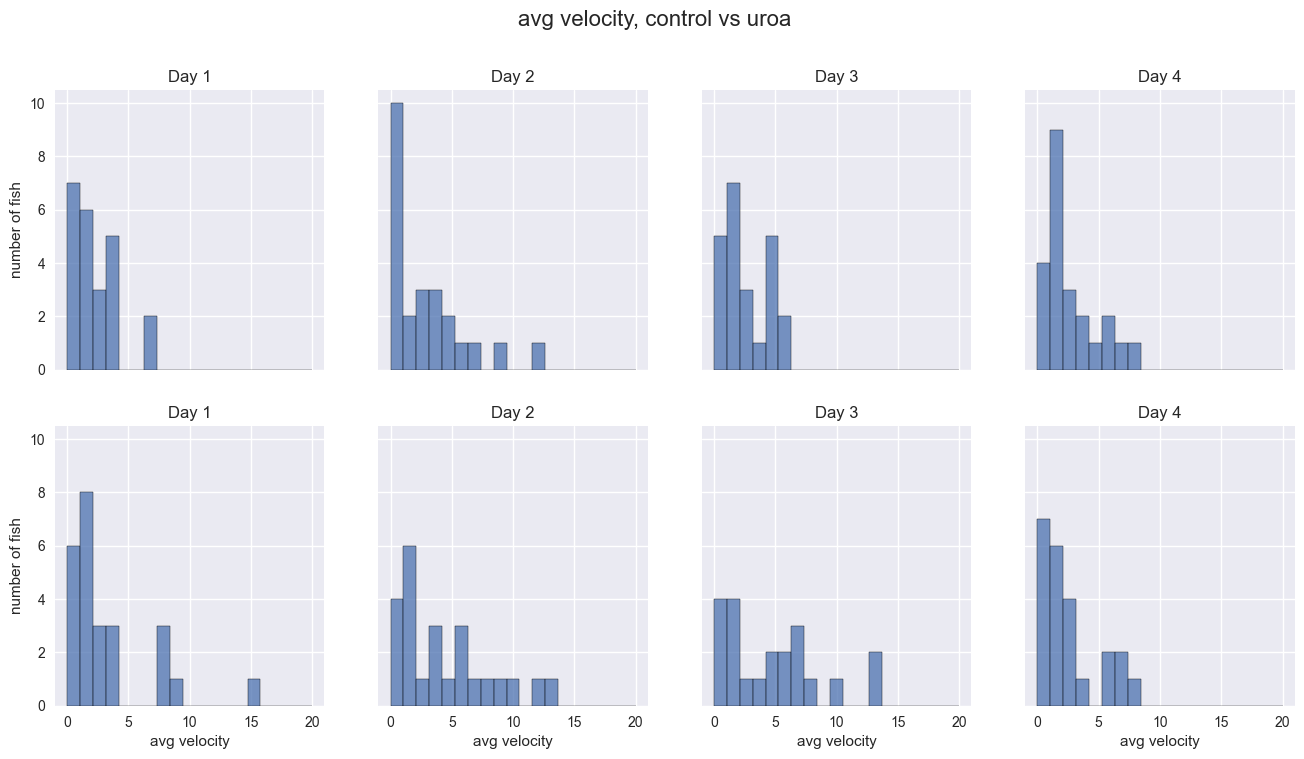

In [76]:
# for vel plots
fig, axes = plt.subplots(2, 4, sharex=True, sharey = True, figsize=(16,8))
plt.suptitle("avg velocity, control vs uroa", fontsize=16) 
for i, axes in enumerate(axes.flat):
    key = keys[i]
    day_df = dist_vel_acc_df.get_group(key)
    bins = np.linspace(0, 20, 20)
    # print(day_df.head(5))
    sns.histplot(day_df["vel"], ax=axes, bins = bins)
    axes.set_title(f"Day {key[1]}")
    axes.set_xlabel("avg velocity")
    axes.set_ylabel("number of fish")


#save png and svg
plt.savefig(dist_vel_acc_save_path+"avg_vel_hist.png")
plt.savefig(dist_vel_acc_save_path+"avg_vel_hist.svg")

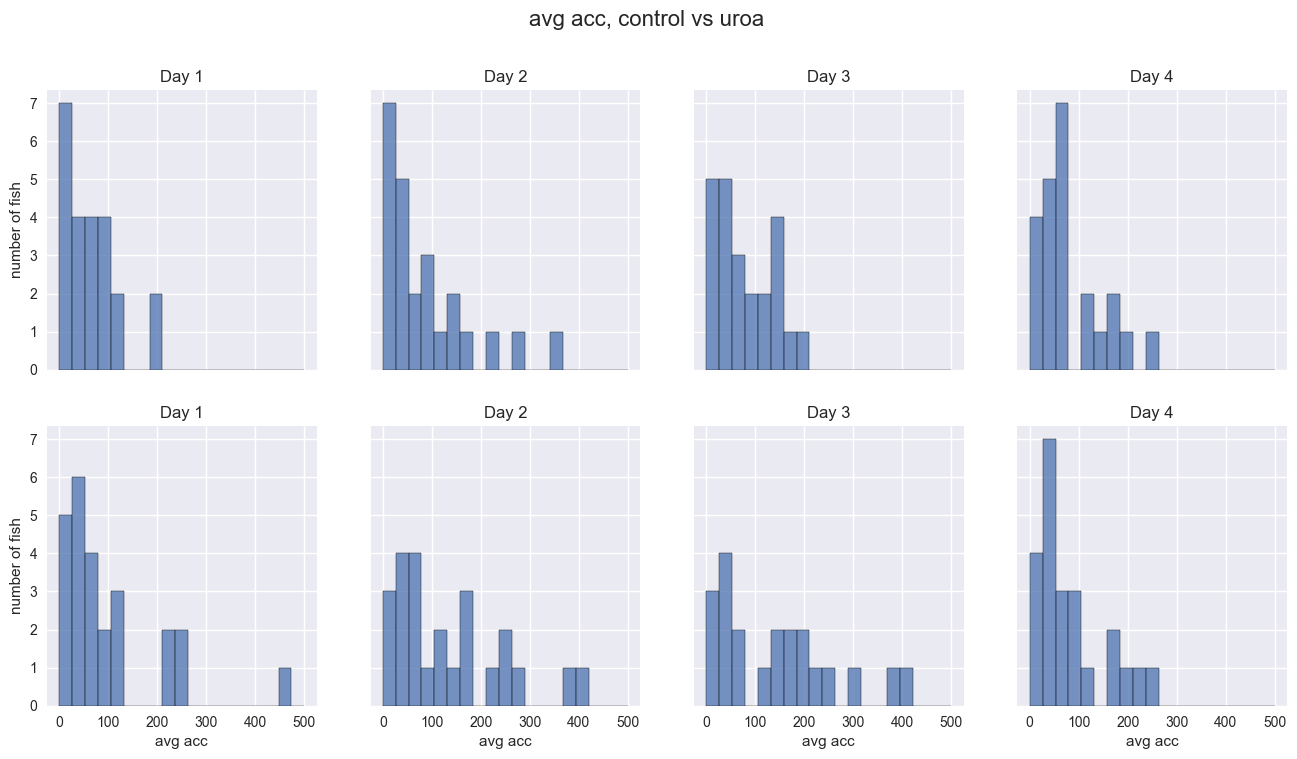

In [77]:
# for acc plots
fig, axes = plt.subplots(2, 4, sharex=True, sharey = True, figsize=(16,8))
plt.suptitle("avg acc, control vs uroa", fontsize=16) 
for i, axes in enumerate(axes.flat):
    key = keys[i]
    day_df = dist_vel_acc_df.get_group(key)
    bins = np.linspace(0, 500, 20)
    # print(day_df.head(5))
    sns.histplot(day_df["acc"], ax=axes, bins = bins)
    axes.set_title(f"Day {key[1]}")
    axes.set_xlabel("avg acc")
    axes.set_ylabel("number of fish")

#save png and svg
plt.savefig(dist_vel_acc_save_path+"avg_acc_hist.png")
plt.savefig(dist_vel_acc_save_path+"avg_acc_hist.svg")

### Polar plot for head direction in LED

In [101]:
#create new df with only the angle data
angle_df = led_df[["name","day", "uroa_control", "angle"]]

#save df
head_direction_save_path = f"./data/visualisation/{EXPERIMENT_SET}/LED_head_direction/"
os.makedirs(head_direction_save_path, exist_ok = True)
angle_df.to_csv(head_direction_save_path+"angle_df.csv", index = False)

#group by day and uroa_control
angle_df = angle_df.groupby(["uroa_control", "day"])

# remove the keys for day 5
keys = list(angle_df.groups.keys())
keys.remove((0,5)) if (0,5) in keys else None
keys.remove((1,5)) if (1,5) in keys else None

for key in keys:
    df = angle_df.get_group(key)
    print(f"{'uroa' if key[0] == 1 else 'control'} day {key[1]}: {len(df)}")


control day 1: 24
control day 2: 24
control day 3: 23
control day 4: 23
uroa day 1: 25
uroa day 2: 24
uroa day 3: 21
uroa day 4: 23


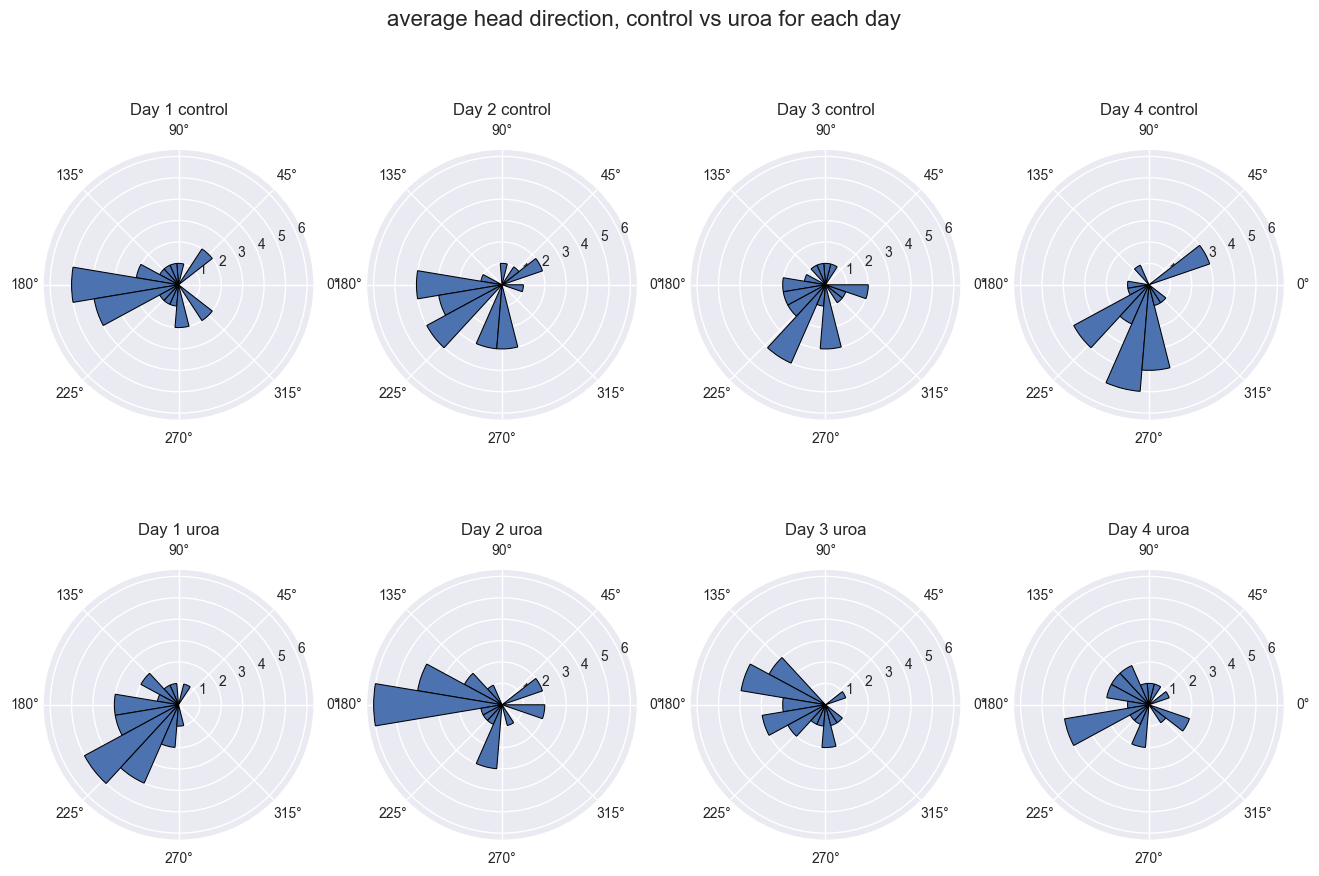

In [79]:
#create a separate polar plot for each day
fig, axs = plt.subplots(2, 4, subplot_kw=dict(projection='polar'), sharex=True, sharey=True, figsize=(16,10))
plt.suptitle("average head direction, control vs uroa for each day", fontsize=16)

for i, ax in enumerate(axs.flat):
    group = angle_df.get_group(keys[i])
    angles = group["angle"].apply(lambda x: x * (np.pi) / 180)  # convert to radians
    # angles = group["angle"]
    bins = np.linspace(0, 2*np.pi, num=20)
    # bins = np.linspace(0, 360, num=20)
    ax.hist(angles, bins=bins, edgecolor="black", linewidth=0.75)
    ax.set_title(f"Day {keys[i][1]} {'uroa' if keys[i][0] == 1 else 'control'}")

#save png and svg
plt.savefig(head_direction_save_path+"head_direction.png")
plt.savefig(head_direction_save_path+"head_direction.svg")

### polar plot of trajectory angle

In [26]:
#create new df with only the angle data
t_angle_df = led_df[["name", "day", "uroa_control", "trajectory_angle"]]

#save df
trajectory_direction_save_path = f"./data/visualisation/{EXPERIMENT_SET}/trajectory_direction/"
os.makedirs(trajectory_direction_save_path, exist_ok = True)
t_angle_df.to_csv(trajectory_direction_save_path+"trajectory_angle_df.csv", index = False)

#group by day and uroa_control
t_angle_df = t_angle_df.groupby(["uroa_control", "day"])

# remove the keys for day 5
keys = list(t_angle_df.groups.keys())
keys.remove((0,5)) if (0,5) in keys else None
keys.remove((1,5)) if (1,5) in keys else None

for key in keys:
    df = t_angle_df.get_group(key)
    print(f"{'uroa' if key[0] == 1 else 'control'} day {key[1]}: {len(df)}")


control day 1: 24
control day 2: 24
control day 3: 23
control day 4: 23
uroa day 1: 25
uroa day 2: 24
uroa day 3: 21
uroa day 4: 23


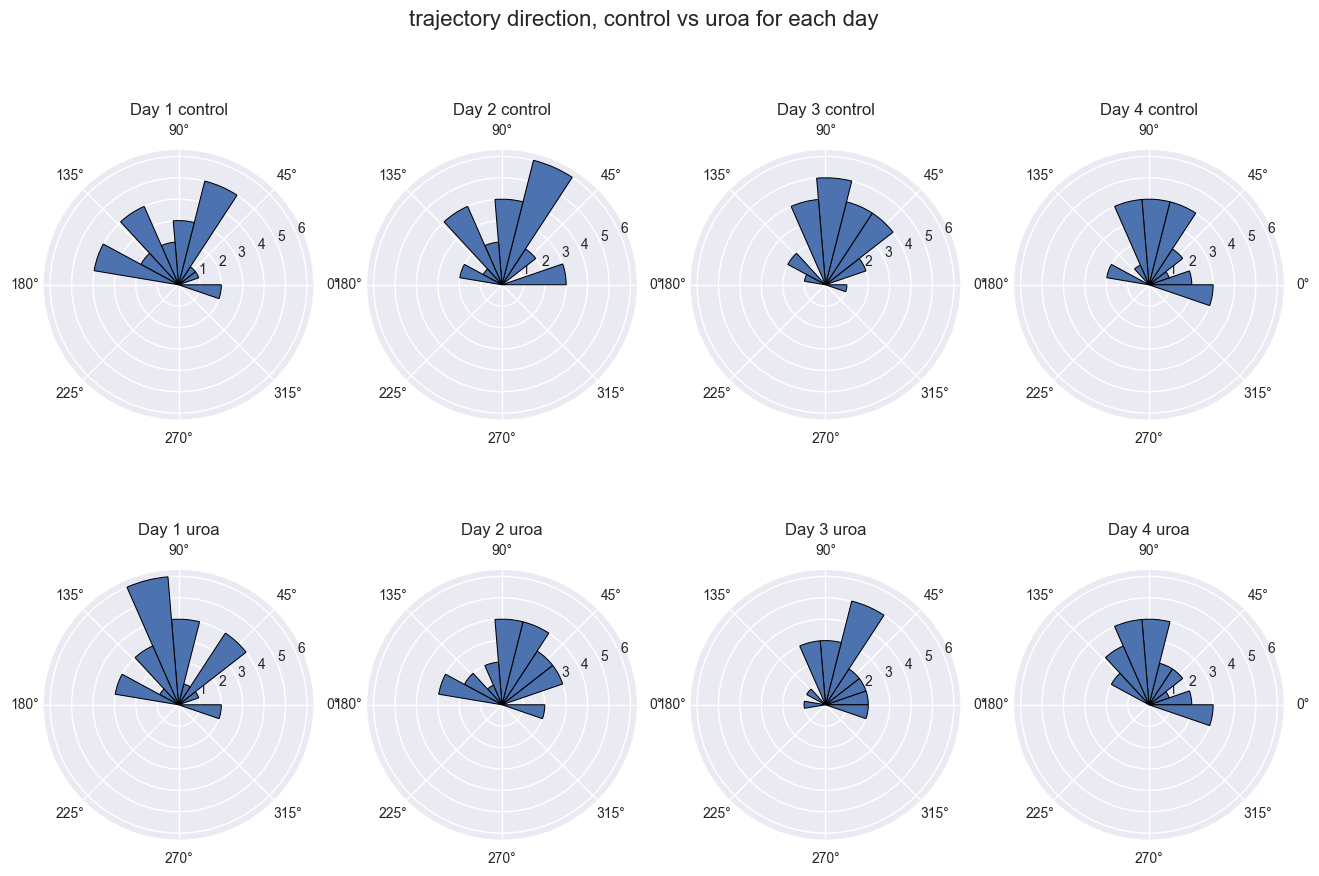

In [27]:
#create a separate polar plot for each day
fig, axs = plt.subplots(2, 4, subplot_kw=dict(projection='polar'), sharex=True, sharey=True, figsize=(16,10))
plt.suptitle("trajectory direction, control vs uroa for each day", fontsize=16)

for i, ax in enumerate(axs.flat):
    group = t_angle_df.get_group(keys[i])
    angles = group["trajectory_angle"].apply(lambda x: x * (np.pi) / 180)  # convert to radians
    # angles = group["angle"]
    bins = np.linspace(0, 2*np.pi, num=20)
    # bins = np.linspace(0, 360, num=20)
    ax.hist(angles, bins=bins, edgecolor="black", linewidth=0.75)
    ax.set_title(f"Day {keys[i][1]} {'uroa' if keys[i][0] == 1 else 'control'}")

#save png and svg
plt.savefig(trajectory_direction_save_path+"trajectory_direction.png")
plt.savefig(trajectory_direction_save_path+"trajectory_direction.svg")

### polar plot for trajectory till end of led 

In [30]:
#create new df with only the angle data
t_end_angle_df = led_df[["name", "day", "uroa_control", "end_trajectory_angle"]]

#save df
end_trajectory_save_path = f"./data/visualisation/{EXPERIMENT_SET}/end_trajectory_direction/"
os.makedirs(end_trajectory_save_path, exist_ok = True)
t_end_angle_df.to_csv(end_trajectory_save_path+"angle_df.csv", index = False)

#group by day and uroa_control
t_end_angle_df = t_end_angle_df.groupby(["uroa_control", "day"])

# remove the keys for day 5
keys = list(t_end_angle_df.groups.keys())
keys.remove((0,5)) if (0,5) in keys else None
keys.remove((1,5)) if (1,5) in keys else None

for key in keys:
    df = t_end_angle_df.get_group(key)
    print(f"{'uroa' if key[0] == 1 else 'control'} day {key[1]}: {len(df)}")


control day 1: 24
control day 2: 24
control day 3: 23
control day 4: 23
uroa day 1: 25
uroa day 2: 24
uroa day 3: 21
uroa day 4: 23


[(0, 1), (0, 2), (0, 3), (0, 4), (1, 1), (1, 2), (1, 3), (1, 4)]


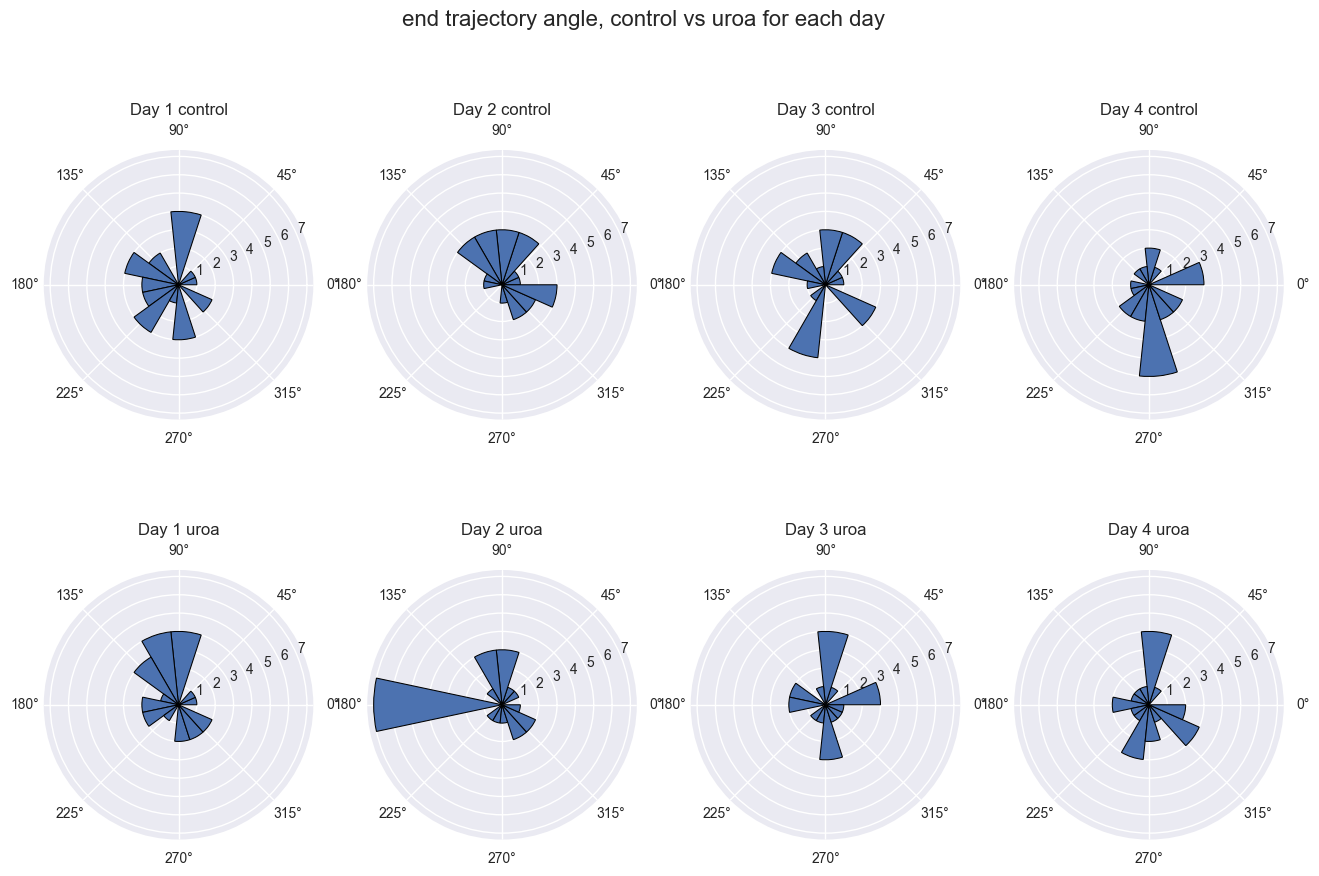

In [31]:
#create a separate polar plot for each day
fig, axs = plt.subplots(2, 4, subplot_kw=dict(projection='polar'), sharex=True, sharey=True, figsize=(16,10))
plt.suptitle("end trajectory angle, control vs uroa for each day", fontsize=16)
print(keys)
for i, ax in enumerate(axs.flat):
    group = t_end_angle_df.get_group(keys[i])
    angles = group["end_trajectory_angle"].apply(lambda x: x * (np.pi) / 180)  # convert to radians
    # angles = group["angle"]
    bins = np.linspace(0, 2*np.pi, num=16)
    # bins = np.linspace(0, 360, num=20)
    ax.hist(angles, bins=bins, edgecolor="black", linewidth=0.75)
    ax.set_title(f"Day {keys[i][1]} {'uroa' if keys[i][0] == 1 else 'control'}")

#save png and svg
plt.savefig(end_trajectory_save_path+"end_trajectory_direction.png")
plt.savefig(end_trajectory_save_path+"end_trajectory_direction.svg")

### histogram for tendency to move upwards

In [103]:
# create a new df with only the y_up data
y_up_df = led_df[["name", "day", "uroa_control", "y_up"]]

#save df
y_up_save_path = f"./data/visualisation/{EXPERIMENT_SET}/LED_y_up/"
os.makedirs(y_up_save_path, exist_ok = True)
y_up_df.to_csv(y_up_save_path+"y_up_df.csv", index = False)

#group by day and uroa_control
y_up_df = y_up_df.groupby(["uroa_control", "day"])

# remove the keys for day 5 if they exist
keys = list(y_up_df.groups.keys())
keys.remove((0, 5)) if (0, 5) in keys else None
keys.remove((1, 5)) if (1, 5) in keys else None

for key in keys:
    df = y_up_df.get_group(key)
    print(f"{'uroa' if key[0] == 1 else 'control'} day {key[1]}: {len(df)}")
    


control day 1: 24
control day 2: 24
control day 3: 23
control day 4: 23
uroa day 1: 25
uroa day 2: 24
uroa day 3: 21
uroa day 4: 23


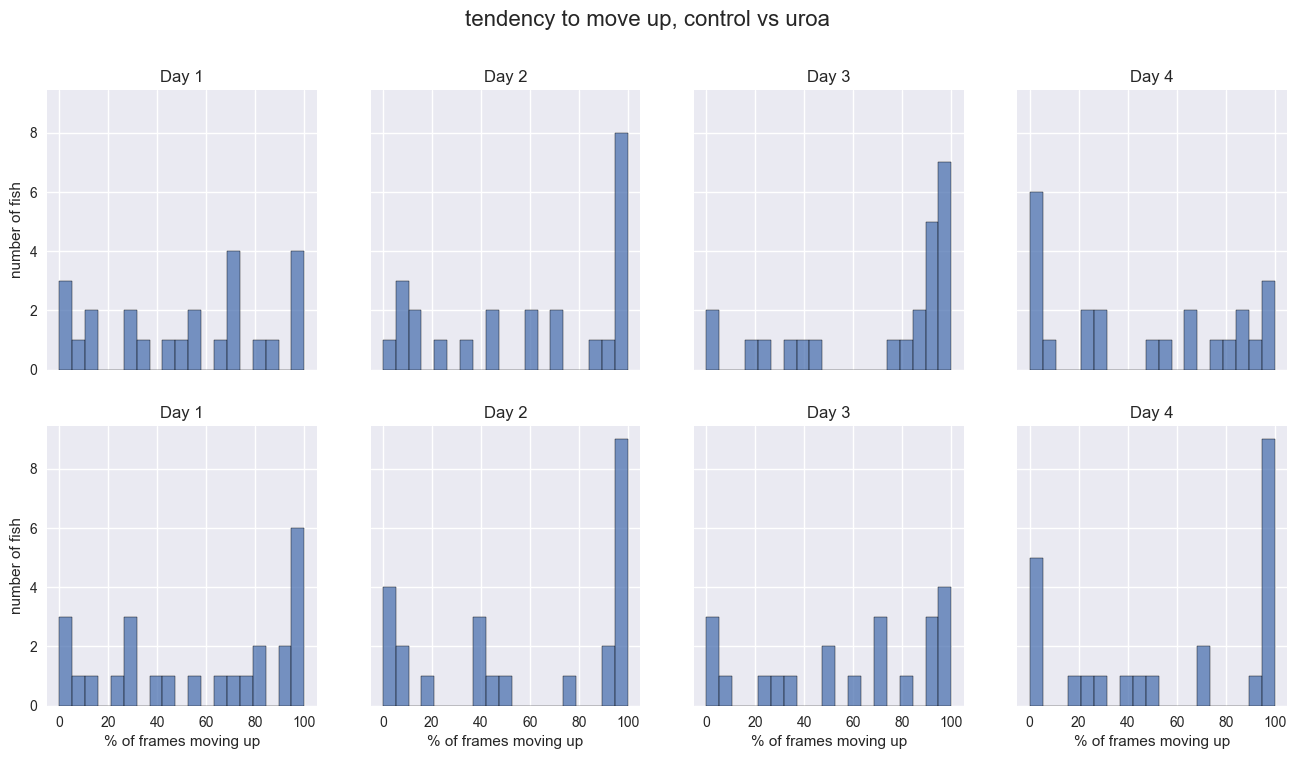

In [81]:
fig, axes = plt.subplots(2, 4, sharex=True, sharey = True, figsize=(16,8))
plt.suptitle("tendency to move up, control vs uroa", fontsize=16)
for i, axes in enumerate(axes.flat):
    key = keys[i]
    day_df = y_up_df.get_group(key)
    bins = np.linspace(0, 100, 20)
    # print(day_df.head(5))
    sns.histplot(day_df["y_up"], ax=axes, bins = bins)
    axes.set_title(f"Day {key[1]}")
    axes.set_xlabel("% of frames moving up")
    axes.set_ylabel("number of fish")

#save png and svg
plt.savefig(y_up_save_path+"y_up_hist.png")
plt.savefig(y_up_save_path+"y_up_hist.svg")


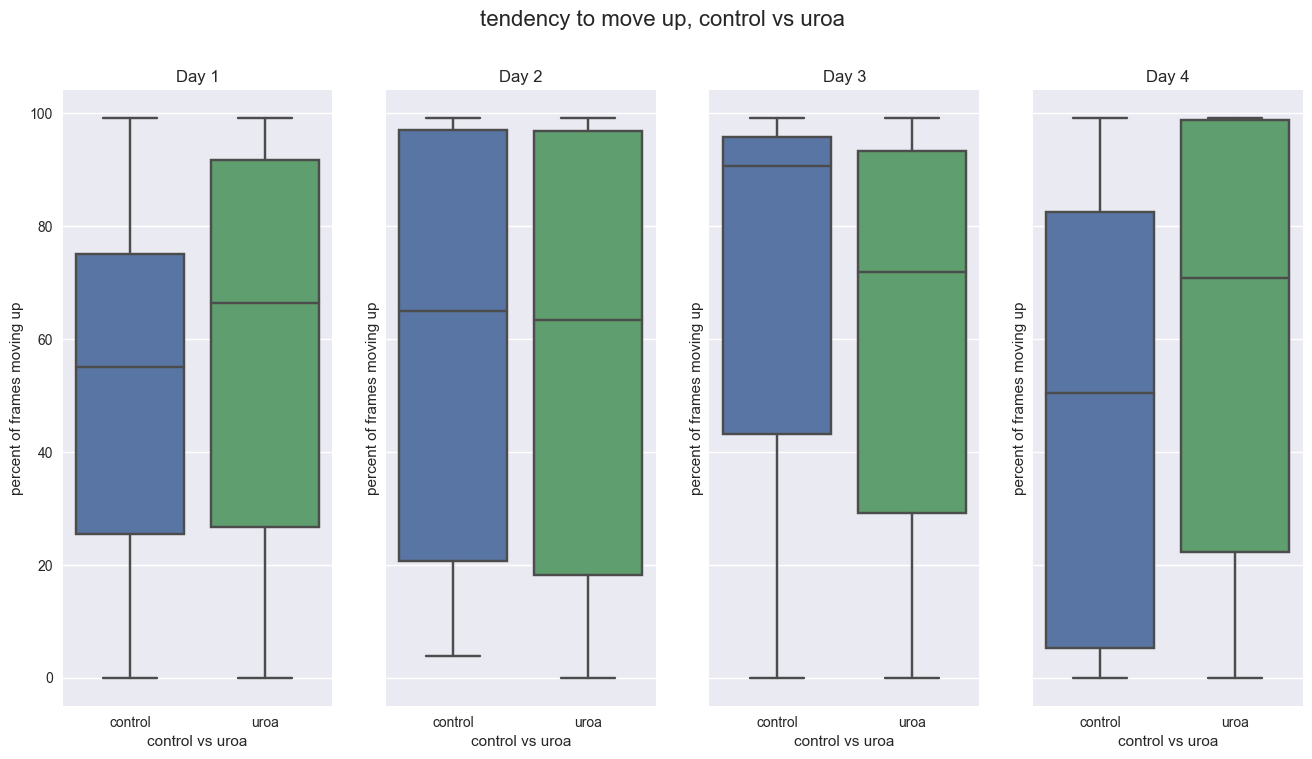

In [82]:
# box plot from the above data by day, total 4 subplots
fig, axes = plt.subplots(1, 4, sharex=True, sharey = True, figsize=(16,8))
plt.suptitle("tendency to move up, control vs uroa", fontsize=16)
for i, axes in enumerate(axes.flat):
    keys_for_day = [keys[i], keys[i+4]]
    day_uro_df = y_up_df.get_group(keys_for_day[1])
    day_control_df = y_up_df.get_group(keys_for_day[0])
    # plot boxplot using sns for both control and urop on same plot
    sns.boxplot(data=[day_control_df["y_up"], day_uro_df["y_up"]], ax=axes)
    axes.set_title(f"Day {keys_for_day[0][1]}")
    #set x axis to control and uroa instead of 0 and 1
    axes.set_xticklabels(["control", "uroa"])
    axes.set_xlabel("control vs uroa")
    axes.set_ylabel("percent of frames moving up")

# save png and svg    
plt.savefig(y_up_save_path+"y_up_day_comaprison_boxplot.png")
plt.savefig(y_up_save_path+"y_up_day_comaprison_boxplot.svg")

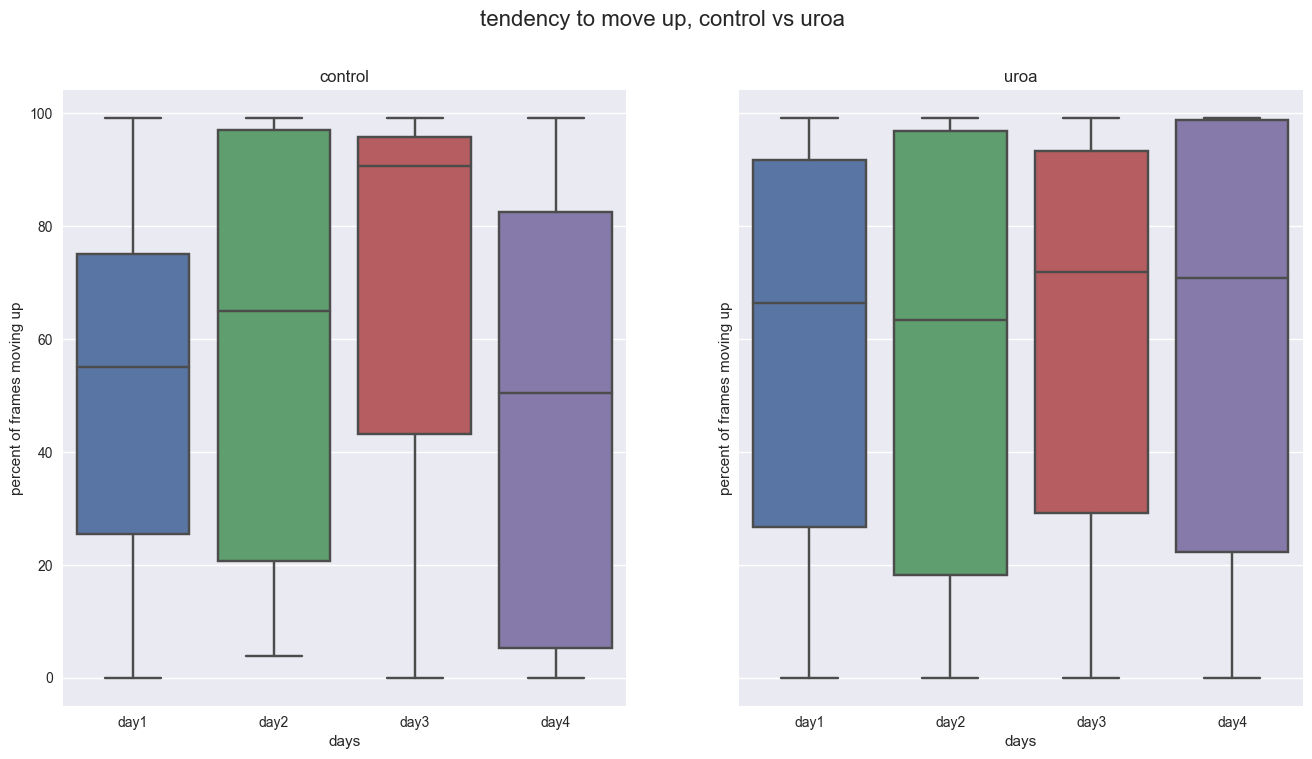

In [83]:
# box plot from the above data, all control in 1 plot, all uro in 1 plot, total 2 subplots
fig, axes = plt.subplots(1, 2, sharex=True, sharey = True, figsize=(16,8))
plt.suptitle("tendency to move up, control vs uroa", fontsize=16)
for i, axes in enumerate(axes.flat):
    keys_for_group = [key for key in keys if key[0] == i]

    #get multiple groups
    day1_df = y_up_df.get_group(keys_for_group[0])
    day2_df = y_up_df.get_group(keys_for_group[1])
    day3_df = y_up_df.get_group(keys_for_group[2])
    day4_df = y_up_df.get_group(keys_for_group[3])

    #plot boxplot
    sns.boxplot(data=[day1_df["y_up"], day2_df["y_up"], day3_df["y_up"], day4_df["y_up"]], ax=axes)
    axes.set_title(f"{'uroa' if i == 1 else 'control'}")
    #set x axis to days instead of 0, 1, 2, 3
    axes.set_xticklabels(["day1", "day2", "day3", "day4"])
    axes.set_xlabel("days")
    axes.set_ylabel("percent of frames moving up")

# save png and svg
plt.savefig(y_up_save_path+"y_up_group_comaprison_boxplot.png")
plt.savefig(y_up_save_path+"y_up_group_comaprison_boxplot.svg")

### polar scatter plot of magnitude of y moved vs trajectory angle

In [104]:
mag_y_trajectory_df = led_df[["name", "day", "uroa_control", "y_mag", "trajectory_angle"]]

# save df
mag_y_trajectory_save_path = f"./data/visualisation/{EXPERIMENT_SET}/LED_mag_y_trajectory_angle/"
os.makedirs(mag_y_trajectory_save_path, exist_ok = True)
mag_y_trajectory_df.to_csv(mag_y_trajectory_save_path+"mag_y_trajectory_df.csv", index = False)

# group by day and uroa_control
mag_y_trajectory_df = mag_y_trajectory_df.groupby(["uroa_control", "day"])
keys = list(mag_y_trajectory_df.groups.keys())
keys.remove((0, 5)) if (0, 5) in keys else None
keys.remove((1, 5)) if (1, 5) in keys else None
for key in keys:
    df = mag_y_trajectory_df.get_group(key)
    print(f"{'uroa' if key[0] == 1 else 'control'} day {key[1]}: {len(df)}")

control day 1: 24
control day 2: 24
control day 3: 23
control day 4: 23
uroa day 1: 25
uroa day 2: 24
uroa day 3: 21
uroa day 4: 23


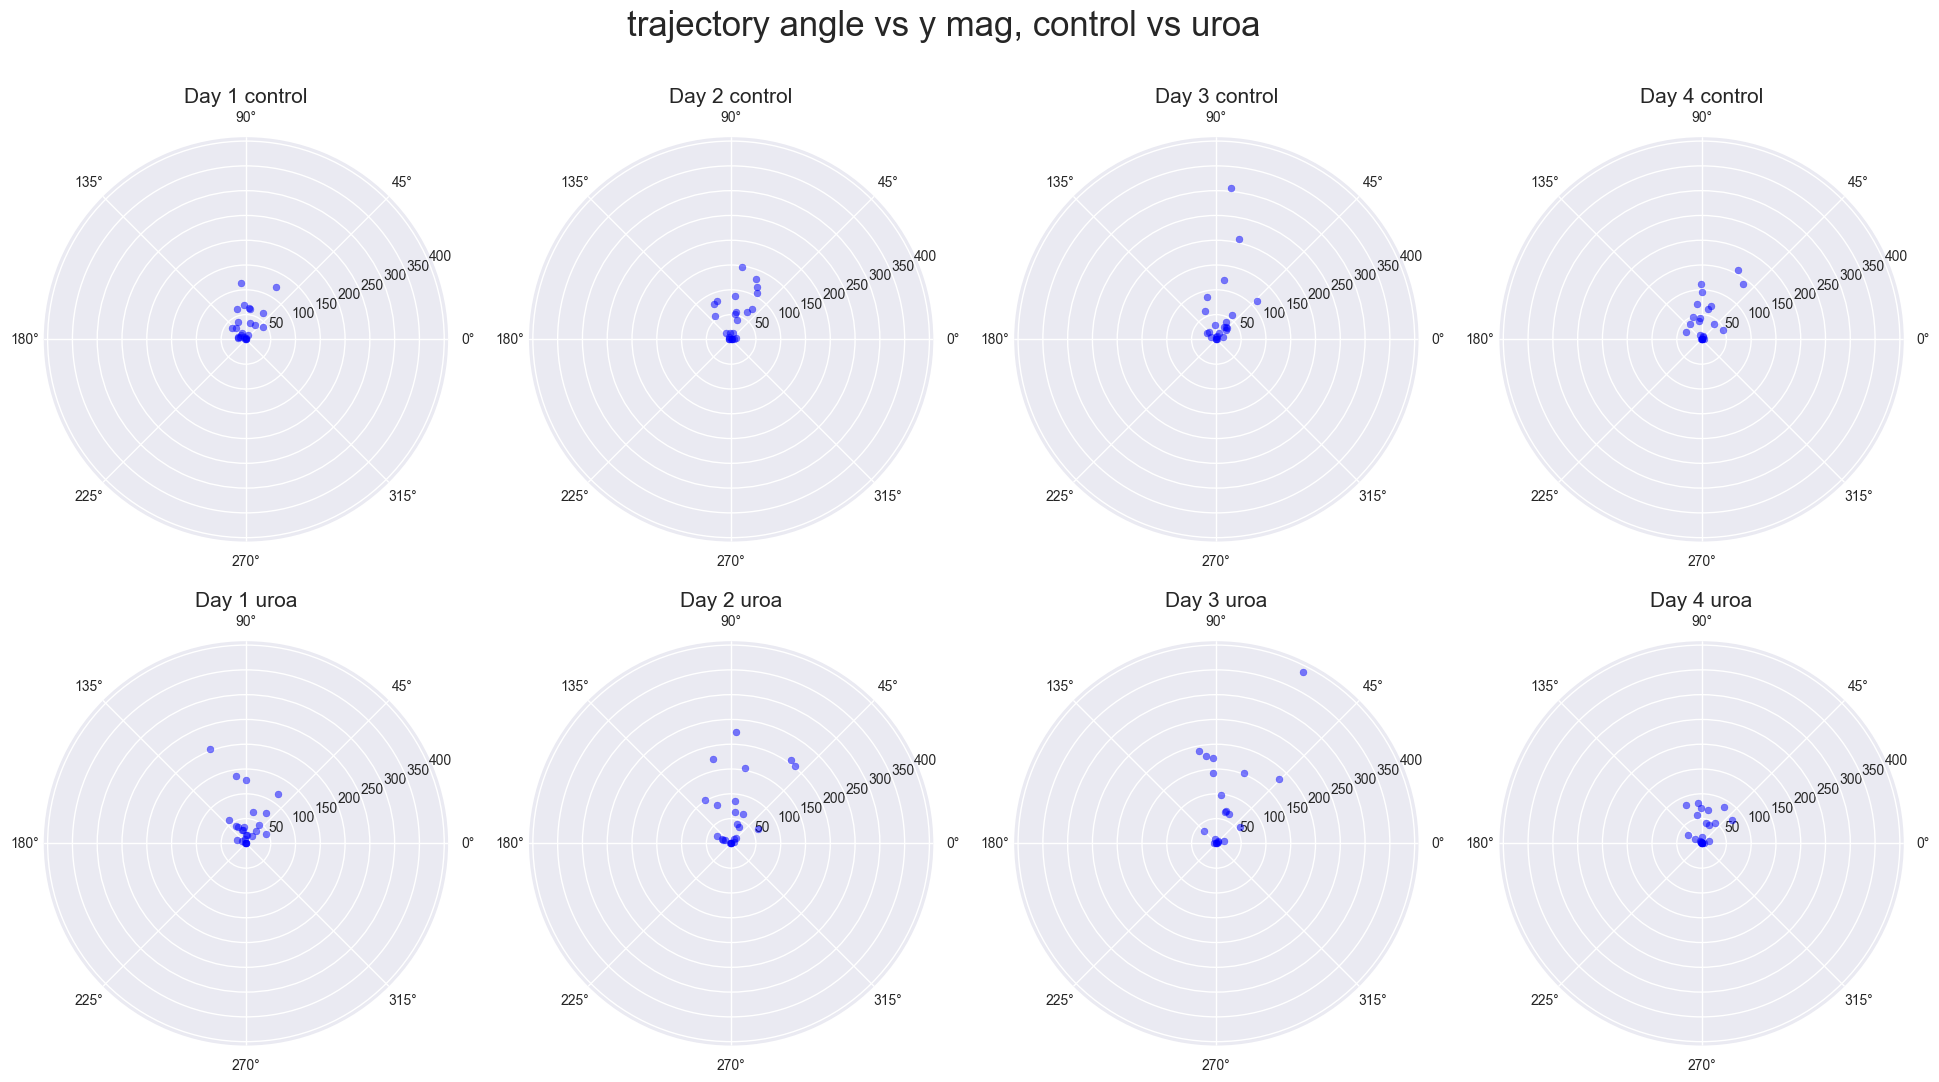

In [85]:
#create a separate polar plot for each day
fig, axs = plt.subplots(2, 4, subplot_kw=dict(projection='polar'), sharex=True, sharey=True, figsize=(24,12))
plt.suptitle("trajectory angle vs y mag, control vs uroa", fontsize=25)
for i, ax in enumerate(axs.flat):
    group = mag_y_trajectory_df.get_group(keys[i])
    angles = group["trajectory_angle"].apply(lambda x: x * (np.pi) / 180)  # convert to radians
    ax.scatter(angles, group["y_mag"], s=25, c='b', alpha=0.5)
    ax.set_title(f"Day {keys[i][1]} {'uroa' if keys[i][0] == 1 else 'control'}", fontsize=15)

#save png and svg
plt.savefig(mag_y_trajectory_save_path+"mag_y_trajectory_angle_polar.png")
plt.savefig(mag_y_trajectory_save_path+"mag_y_trajectory_angle_polar.svg")

### starting coords vs trajectory polar plot

This puts LED at the center of the polar plot essentially, and we plot how far does each fish start from the LED. If they are starting from a lower height, they are radially outwards (we want this so that those who started closer are shown as closer to LED, plus their trajectory angle does not matter too much)



In [105]:
start_y_trajectory_df = led_df[["name","day", "uroa_control", "start_y_from_led", "trajectory_angle"]]

# save df
start_y_trajectory_save_path = f"./data/visualisation/{EXPERIMENT_SET}/LED_start_y_trajectory_angle/"
os.makedirs(start_y_trajectory_save_path, exist_ok = True)
start_y_trajectory_df.to_csv(start_y_trajectory_save_path+"start_y_trajectory_df.csv", index = False)

# group by day and uroa_control
start_y_trajectory_df = start_y_trajectory_df.groupby(["uroa_control", "day"])
keys = list(start_y_trajectory_df.groups.keys())
keys.remove((0, 5)) if (0, 5) in keys else None
keys.remove((1, 5)) if (1, 5) in keys else None
for key in keys:
    df = start_y_trajectory_df.get_group(key)
    print(f"{'uroa' if key[0] == 1 else 'control'} day {key[1]}: {len(df)}")

control day 1: 24
control day 2: 24
control day 3: 23
control day 4: 23
uroa day 1: 25
uroa day 2: 24
uroa day 3: 21
uroa day 4: 23


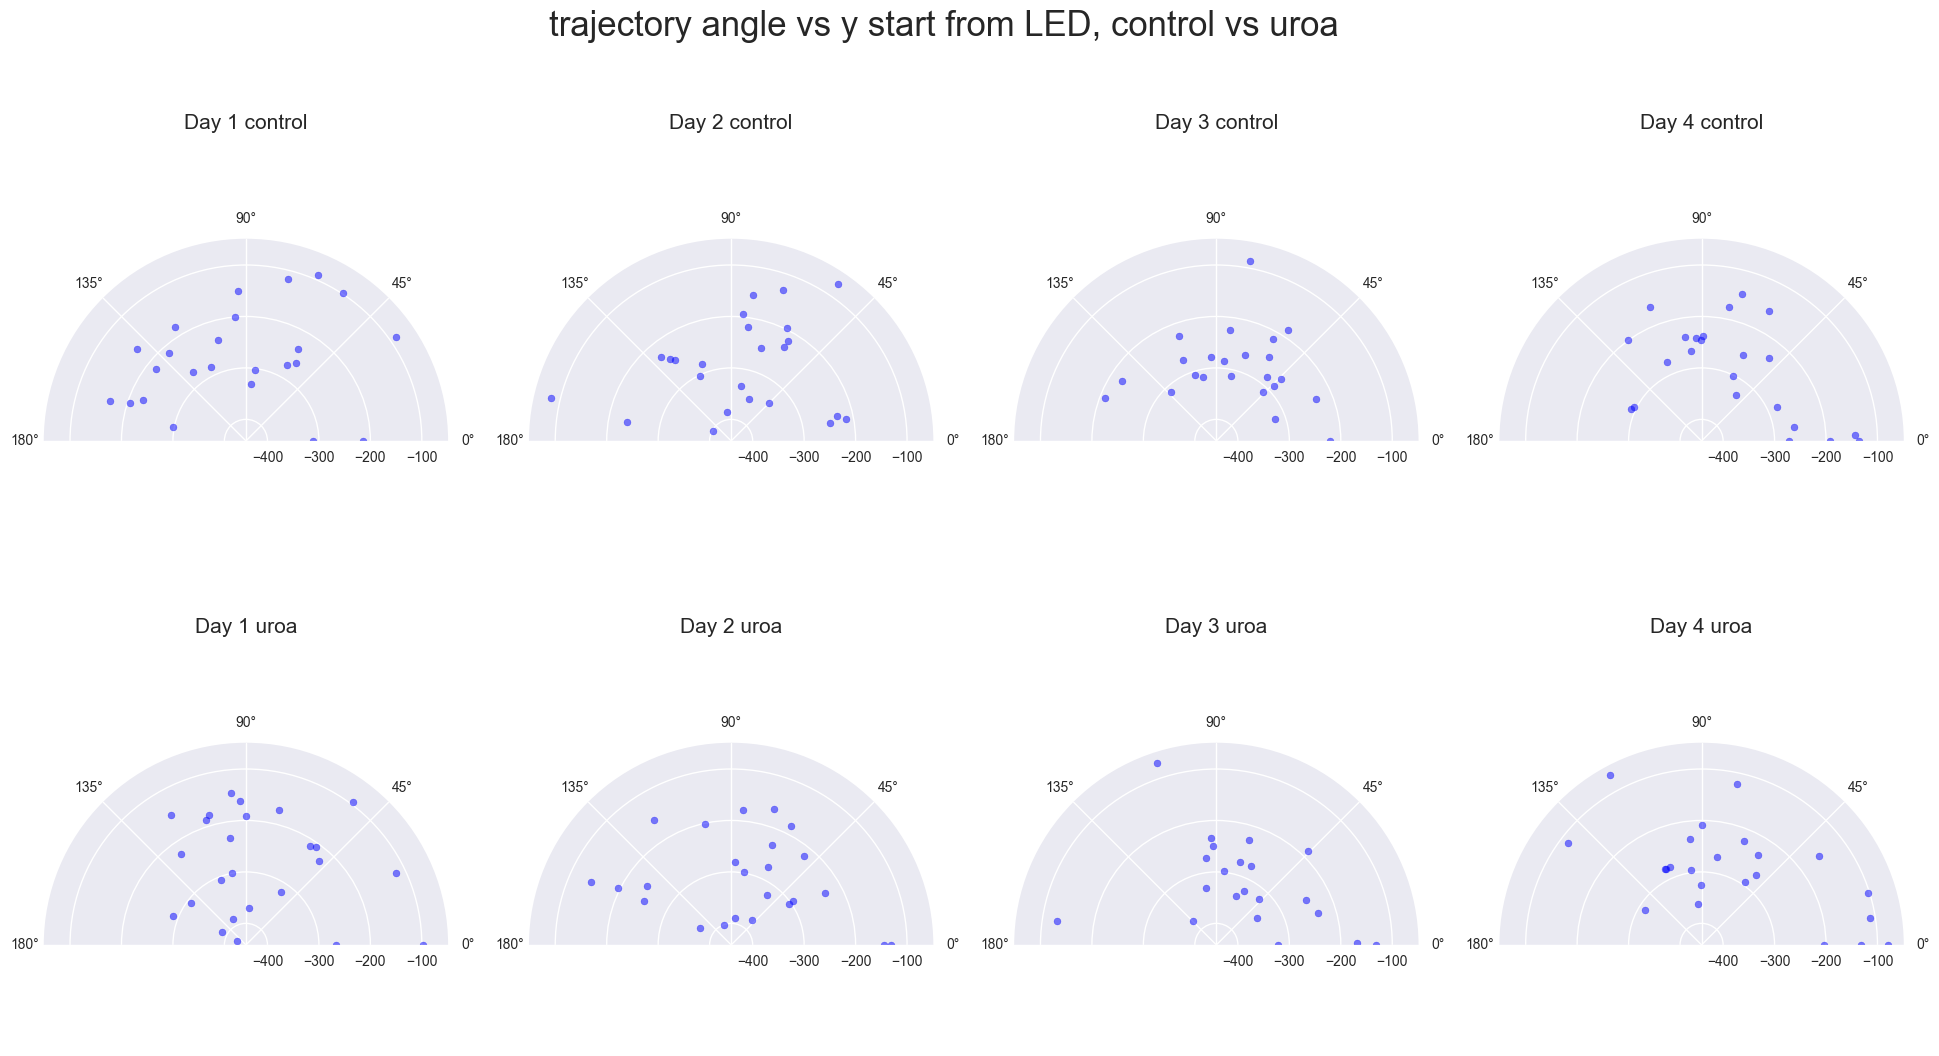

In [104]:
#create a separate polar plot for each day
fig, axs = plt.subplots(2, 4, subplot_kw=dict(projection='polar'), sharex=True, sharey=True, figsize=(24,12))

# create the fig,axs but limit the plot from 0 to 180 degrees
plt.suptitle("trajectory angle vs y start from LED, control vs uroa", fontsize=25)
for i, ax in enumerate(axs.flat):
    group = start_y_trajectory_df.get_group(keys[i])
    angles = group["trajectory_angle"].apply(lambda x: x * (np.pi) / 180)  # convert to radians
    ax.scatter(angles, group["start_y_from_led"], s=25, c='b', alpha=0.5)
    ax.set_title(f"Day {keys[i][1]} {'uroa' if keys[i][0] == 1 else 'control'}", fontsize=15)
    # set radial labels -400 to -50 in steps of 100 instead of 50
    ax.set_yticks([-400, -300, -200, -100])
    # set angular limit to 0-180 degrees
    ax.set_xlim(0, np.pi)
    # set angular labels to 0-180 degrees
    ax.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])


# save png and svg
plt.savefig(start_y_trajectory_save_path+"start_y_trajectory_angle_polar.png")
plt.savefig(start_y_trajectory_save_path+"start_y_trajectory_angle_polar.svg")


### 4-in-1 polar scatter plot
This plot includes start wrt. LED y position and trajectory angle (same as above) but also includes magnitude of movement (red to blue for more movement to less) and % of frames above start position as size of the dot.

In [55]:
start_y_trajectory_ymag_yup_df = led_df[["name","day", "uroa_control", "start_y_from_led", "trajectory_angle", "y_mag", "y_up"]]
print(start_y_trajectory_ymag_yup_df.head())
# multiply start y by -1 to make it positive using .loc. 
# This makes led at the inside of the circle
start_y_trajectory_ymag_yup_df["start_y_from_led"] = start_y_trajectory_ymag_yup_df["start_y_from_led"].apply(lambda x: x * -1, )
# multiply trajectory angle by -1 to make it positive using .loc. 
# this makes the trajectory angle go clockwise
start_y_trajectory_ymag_yup_df["trajectory_angle"] = start_y_trajectory_ymag_yup_df["trajectory_angle"].apply(lambda x: x * -1)

# print(start_y_trajectory_ymag_yup_df.head())

# save df
start_y_trajectory_ymag_yup_save_path = f"./data/visualisation/{EXPERIMENT_SET}/start_y_trajectory_ymag_yup/"
os.makedirs(start_y_trajectory_ymag_yup_save_path, exist_ok = True)
start_y_trajectory_ymag_yup_df.to_csv(start_y_trajectory_ymag_yup_save_path+"start_y_trajectory_ymag_yup_df.csv", index = False)

# group by day and uroa_control
start_y_trajectory_ymag_yup_df = start_y_trajectory_ymag_yup_df.groupby(["uroa_control", "day"])
keys = list(start_y_trajectory_ymag_yup_df.groups.keys())
keys.remove((0, 5)) if (0, 5) in keys else None
keys.remove((1, 5)) if (1, 5) in keys else None
for key in keys:
    df = start_y_trajectory_ymag_yup_df.get_group(key)
    print(f"{'uroa' if key[0] == 1 else 'control'} day {key[1]}: {len(df)}")

   day  uroa_control  start_y_from_led  trajectory_angle       y_mag  \
0    1             1        -226.11932         48.977349   20.036144   
1    1             1        -230.87733         98.529466  137.929552   
2    1             1        -213.24283         56.991432  119.822700   
3    1             1        -178.57547        105.711435    8.257198   
4    1             1        -306.15125        110.804269  203.850662   

        y_up  
0  66.386555  
1  91.666667  
2  79.831933  
3   6.034483  
4  97.500000  
   day  uroa_control  start_y_from_led  trajectory_angle       y_mag  \
0    1             1         226.11932        -48.977349   20.036144   
1    1             1         230.87733        -98.529466  137.929552   
2    1             1         213.24283        -56.991432  119.822700   
3    1             1         178.57547       -105.711435    8.257198   
4    1             1         306.15125       -110.804269  203.850662   

        y_up  
0  66.386555  
1  91.666667  

/var/folders/n_/64hnj2wj2z9bjdmhv2pyfz6h0000gp/T/ipykernel_4613/1465250122.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  start_y_trajectory_ymag_yup_df["start_y_from_led"] = start_y_trajectory_ymag_yup_df["start_y_from_led"].apply(lambda x: x * -1, )
/var/folders/n_/64hnj2wj2z9bjdmhv2pyfz6h0000gp/T/ipykernel_4613/1465250122.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  start_y_trajectory_ymag_yup_df["trajectory_angle"] = start_y_trajectory_ymag_yup_df["trajectory_angle"].apply(lambda x: x * -1)


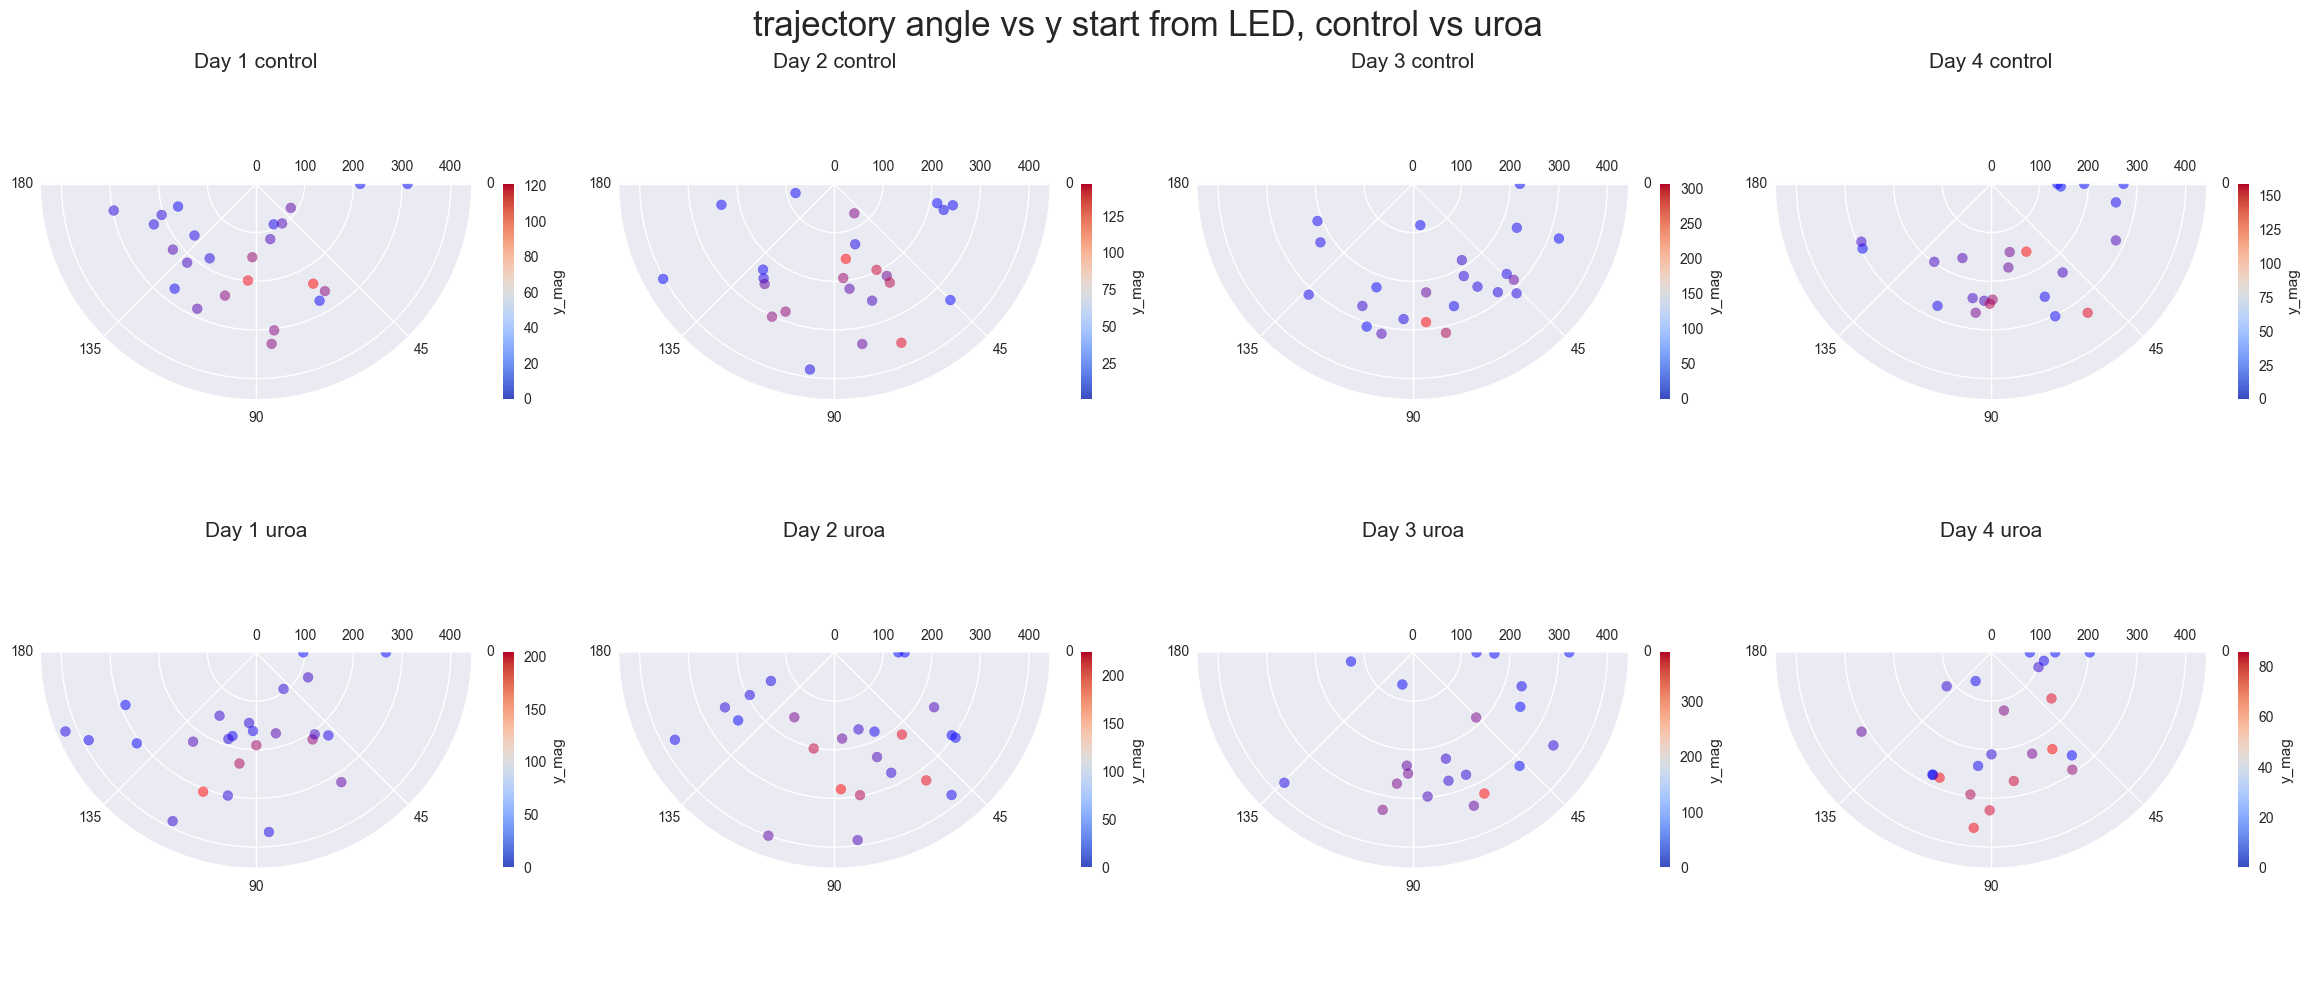

In [75]:
#create a separate polar plot for each day
fig, axs = plt.subplots(2, 4, subplot_kw=dict(projection='polar'), sharex=True, sharey=True, figsize=(24,10))

# create the fig,axs
plt.suptitle("trajectory angle vs y start from LED, control vs uroa", fontsize=25)
for i, ax in enumerate(axs.flat):
    group = start_y_trajectory_ymag_yup_df.get_group(keys[i])
    angles = group["trajectory_angle"].apply(lambda x: x * (np.pi) / 180)  # convert to radians
    # size = group["y_up"] #normalise the size of the points to 25 - 75 (max size)
    # size = size.apply(lambda x: (x - size.min()) / (size.max() - size.min()) * 50 + 25)
    color = group["y_mag"] #normalise the color of the points to 0 - 1 (max color)
    color = color.apply(lambda x: (x - color.min()) / (color.max() - color.min()))
    color = color.apply(lambda x: (x, 0, 1-x, 1)) # red means y_up is high, blue means y_up is low
    ax.scatter(angles, group["start_y_from_led"], s=50, c=color, alpha=0.5)
    ax.set_title(f"Day {keys[i][1]} {'uroa' if keys[i][0] == 1 else 'control'}", fontsize=15)
    # set radial labels -400 to -50 in steps of 100 instead of 50
    # ax.set_yticks([-400, -300, -200, -100])
    ax.set_yticks([0, 100, 200, 300, 400])
    # set angular limit to 0-180 degrees
    ax.set_xlim(0, -np.pi)
    # set angular labels to 0-180 degrees
    ax.set_xticks([0, -np.pi/4, -np.pi/2, -3*np.pi/4, -np.pi])
    ax.set_xticklabels(["0", "45", "90", "135", "180"])
    # show color scale used for y_mag. set values to min and max of y_mag   
    #TODO fix colorbar
    sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(vmin=group["y_mag"].min(), vmax=group["y_mag"].max()))
    plt.colorbar(sm, ax=ax, shrink=0.5, label="y_mag")
    plt.tight_layout()

# save png and svg
plt.savefig(start_y_trajectory_ymag_yup_save_path+"start_y_trajectory_angle_ymag_yup.png")
plt.savefig(start_y_trajectory_ymag_yup_save_path+"start_y_trajectory_angle_ymag_yup.svg")


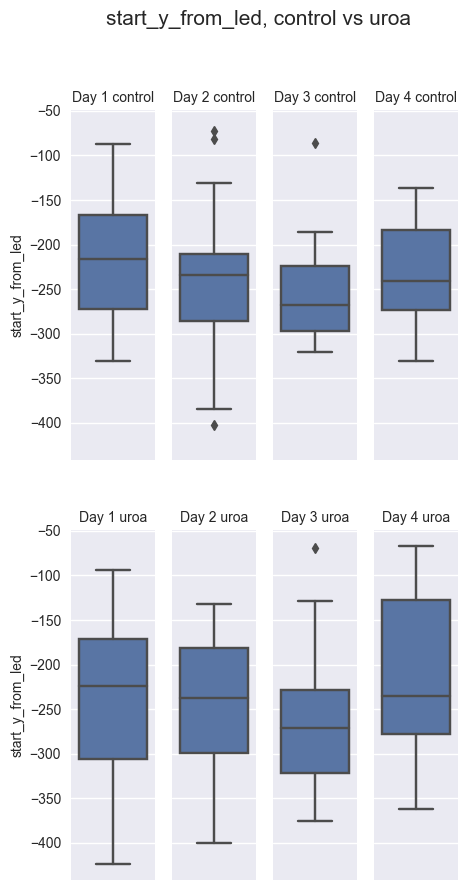

In [90]:
# creating vertical boxplot for each day for start_y_from_led
fig, axs = plt.subplots(2, 4, figsize=(5,10), sharey=True, sharex=True)
plt.suptitle("start_y_from_led, control vs uroa", fontsize=15)
for i, ax in enumerate(axs.flat):
    group = start_y_trajectory_ymag_yup_df.get_group(keys[i])
    sns.boxplot(x="uroa_control", y="start_y_from_led", data=group, ax=ax)
    ax.set_title(f"Day {keys[i][1]} {'uroa' if keys[i][0] == 1 else 'control'}", fontsize=10)
    # remove the x axis label and ticks for all columns
    ax.set_xlabel("")
    ax.set_xticks([])
    # remove the y axis label for all columns
    ax.set_ylabel("") if i not in [0,4] else ax.set_ylabel("start_y_from_led", fontsize=10)

# save png and svg
plt.savefig(start_y_trajectory_ymag_yup_save_path+"start_y_boxplot.png")
plt.savefig(start_y_trajectory_ymag_yup_save_path+"start_y_boxplot.svg")



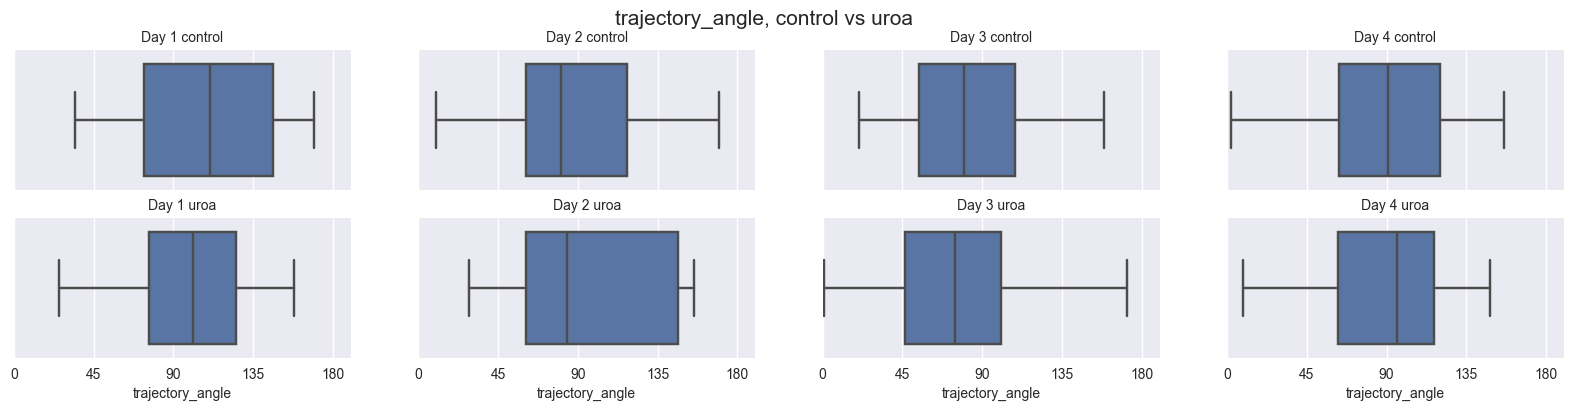

In [109]:
# # creating horizontal boxplot for each day for trajectory_angle
fig, axs = plt.subplots(2, 4, figsize=(20,4), sharey=True, sharex=True)
plt.suptitle("trajectory_angle, control vs uroa", fontsize=15)
for i, ax in enumerate(axs.flat):
    group = start_y_trajectory_ymag_yup_df.get_group(keys[i])
    # limit boxplot to 180 degrees
    # sns.boxplot(y="uroa_control", x="trajectory_angle", data=group, ax=ax, orient="h")    
    ax.set_xlim(0, 190)
    # set the x axis ticks to 0, 45, 90, 135, 180
    ax.set_xticks([0, 45, 90, 135, 180])
    sns.boxplot(y="uroa_control", x="trajectory_angle", data=group, ax=ax, orient="h")
    ax.set_title(f"Day {keys[i][1]} {'uroa' if keys[i][0] == 1 else 'control'}", fontsize=10)
    # remove the x axis label for upper columns
    ax.set_xlabel("") if i not in [4,5,6,7] else ax.set_xlabel("trajectory_angle", fontsize=10)
    # remove the y axis label and ticks for all columns
    ax.set_ylabel("")
    ax.set_yticks([])

# save png and svg
plt.savefig(start_y_trajectory_ymag_yup_save_path+"trajectory_angle_boxplot.png")
plt.savefig(start_y_trajectory_ymag_yup_save_path+"trajectory_angle_boxplot.svg")

### Statistical significance plots using DABEST proportion plots

In [17]:
import dabest

In [22]:
# columns to use for the dabest analysis
parameters = led_df.columns[3:]
print(parameters.values)

# save path for the dabest plots
dabest_save_path = f"./data/visualisation/{EXPERIMENT_SET}/dabest_plots/"
os.makedirs(dabest_save_path, exist_ok=True)


# pandas ignore futurewarning and userwarning
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)


['dist' 'vel' 'acc' 'head_angle' 'dist_surface' 'y_up' 'y_mag'
 'trajectory_angle' 'start_y_from_led' 'end_trajectory_angle']


dist


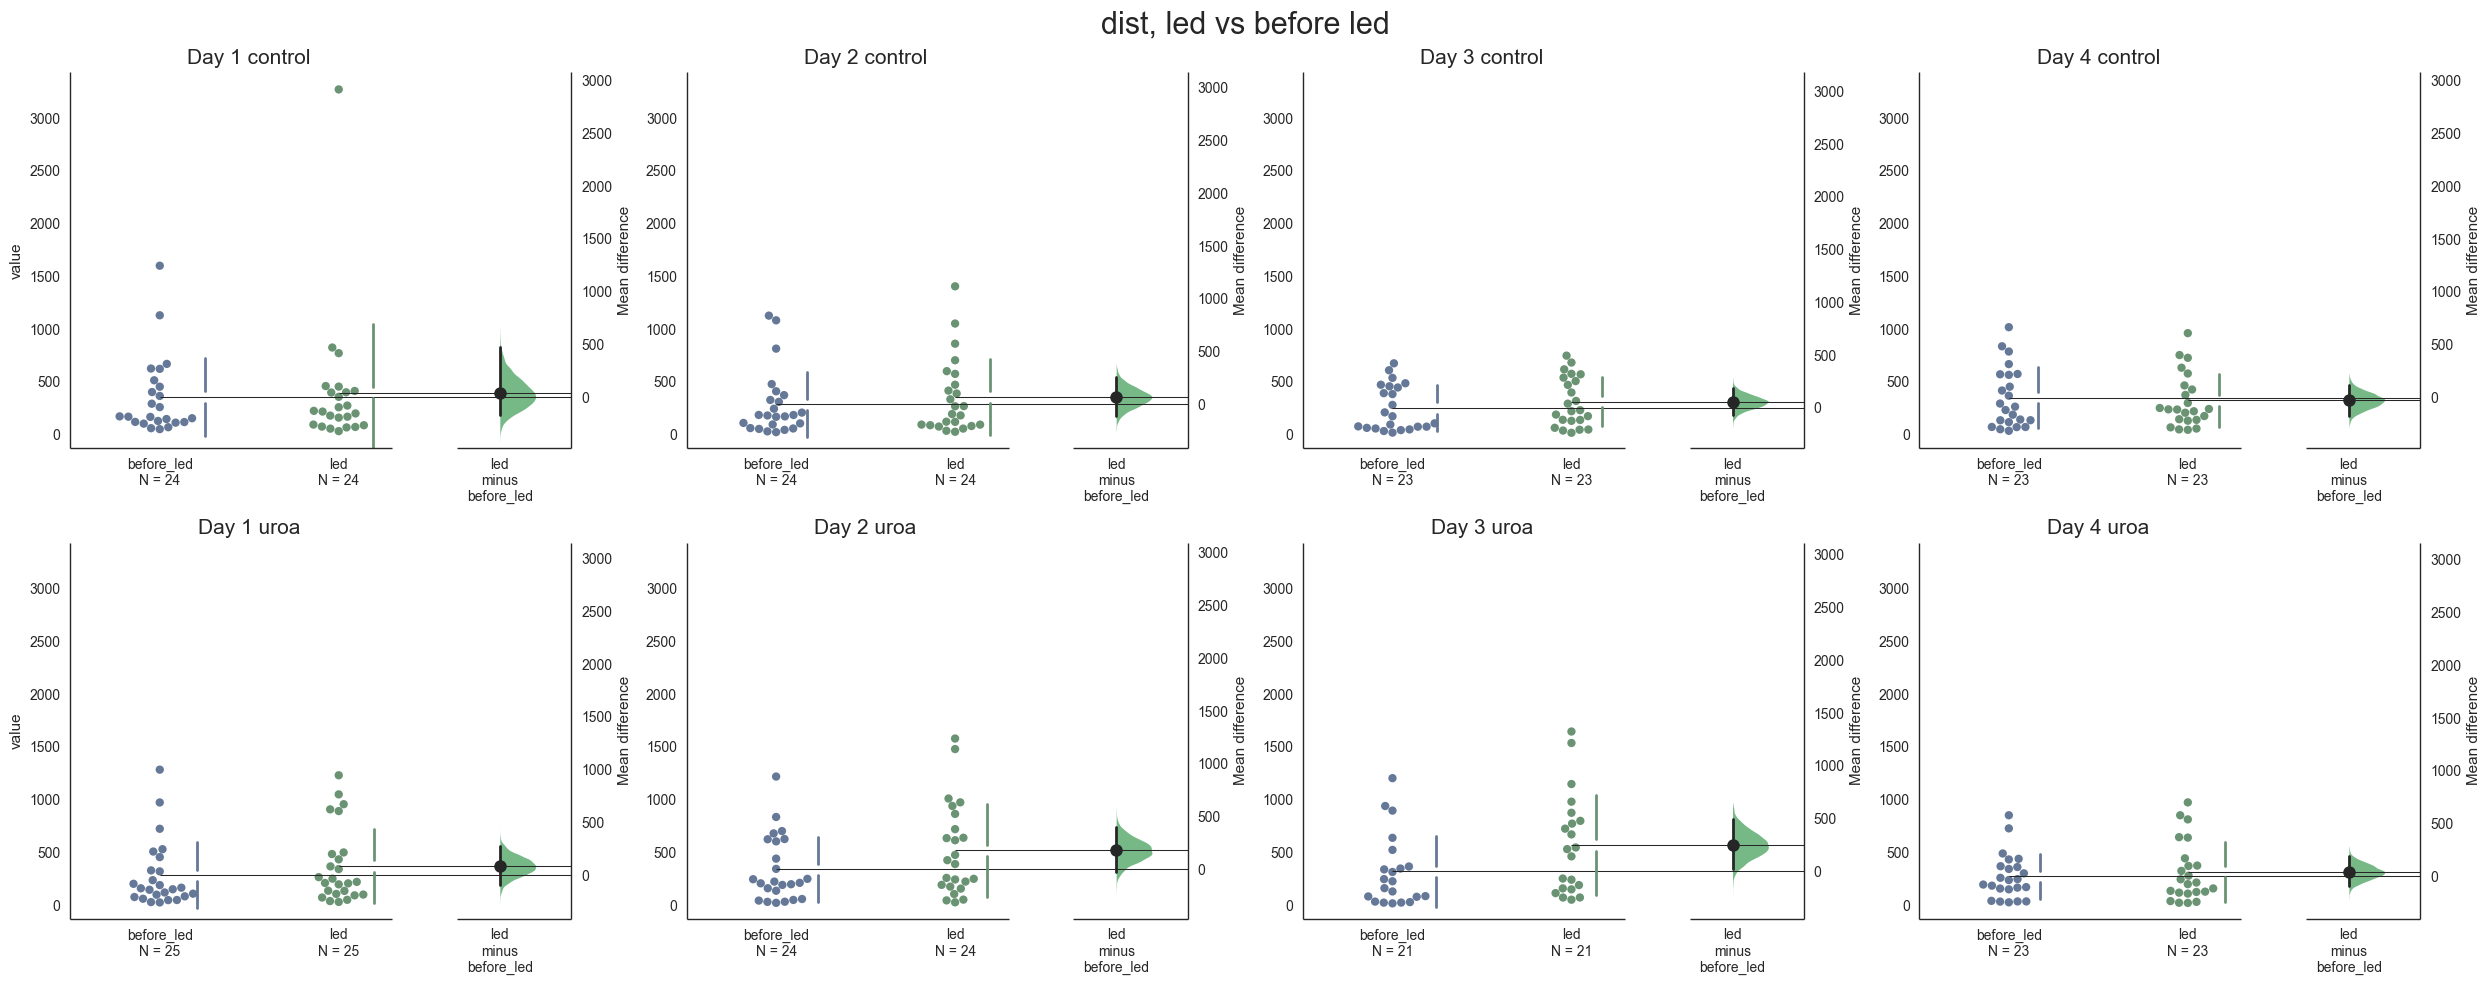

vel


<Figure size 800x550 with 0 Axes>

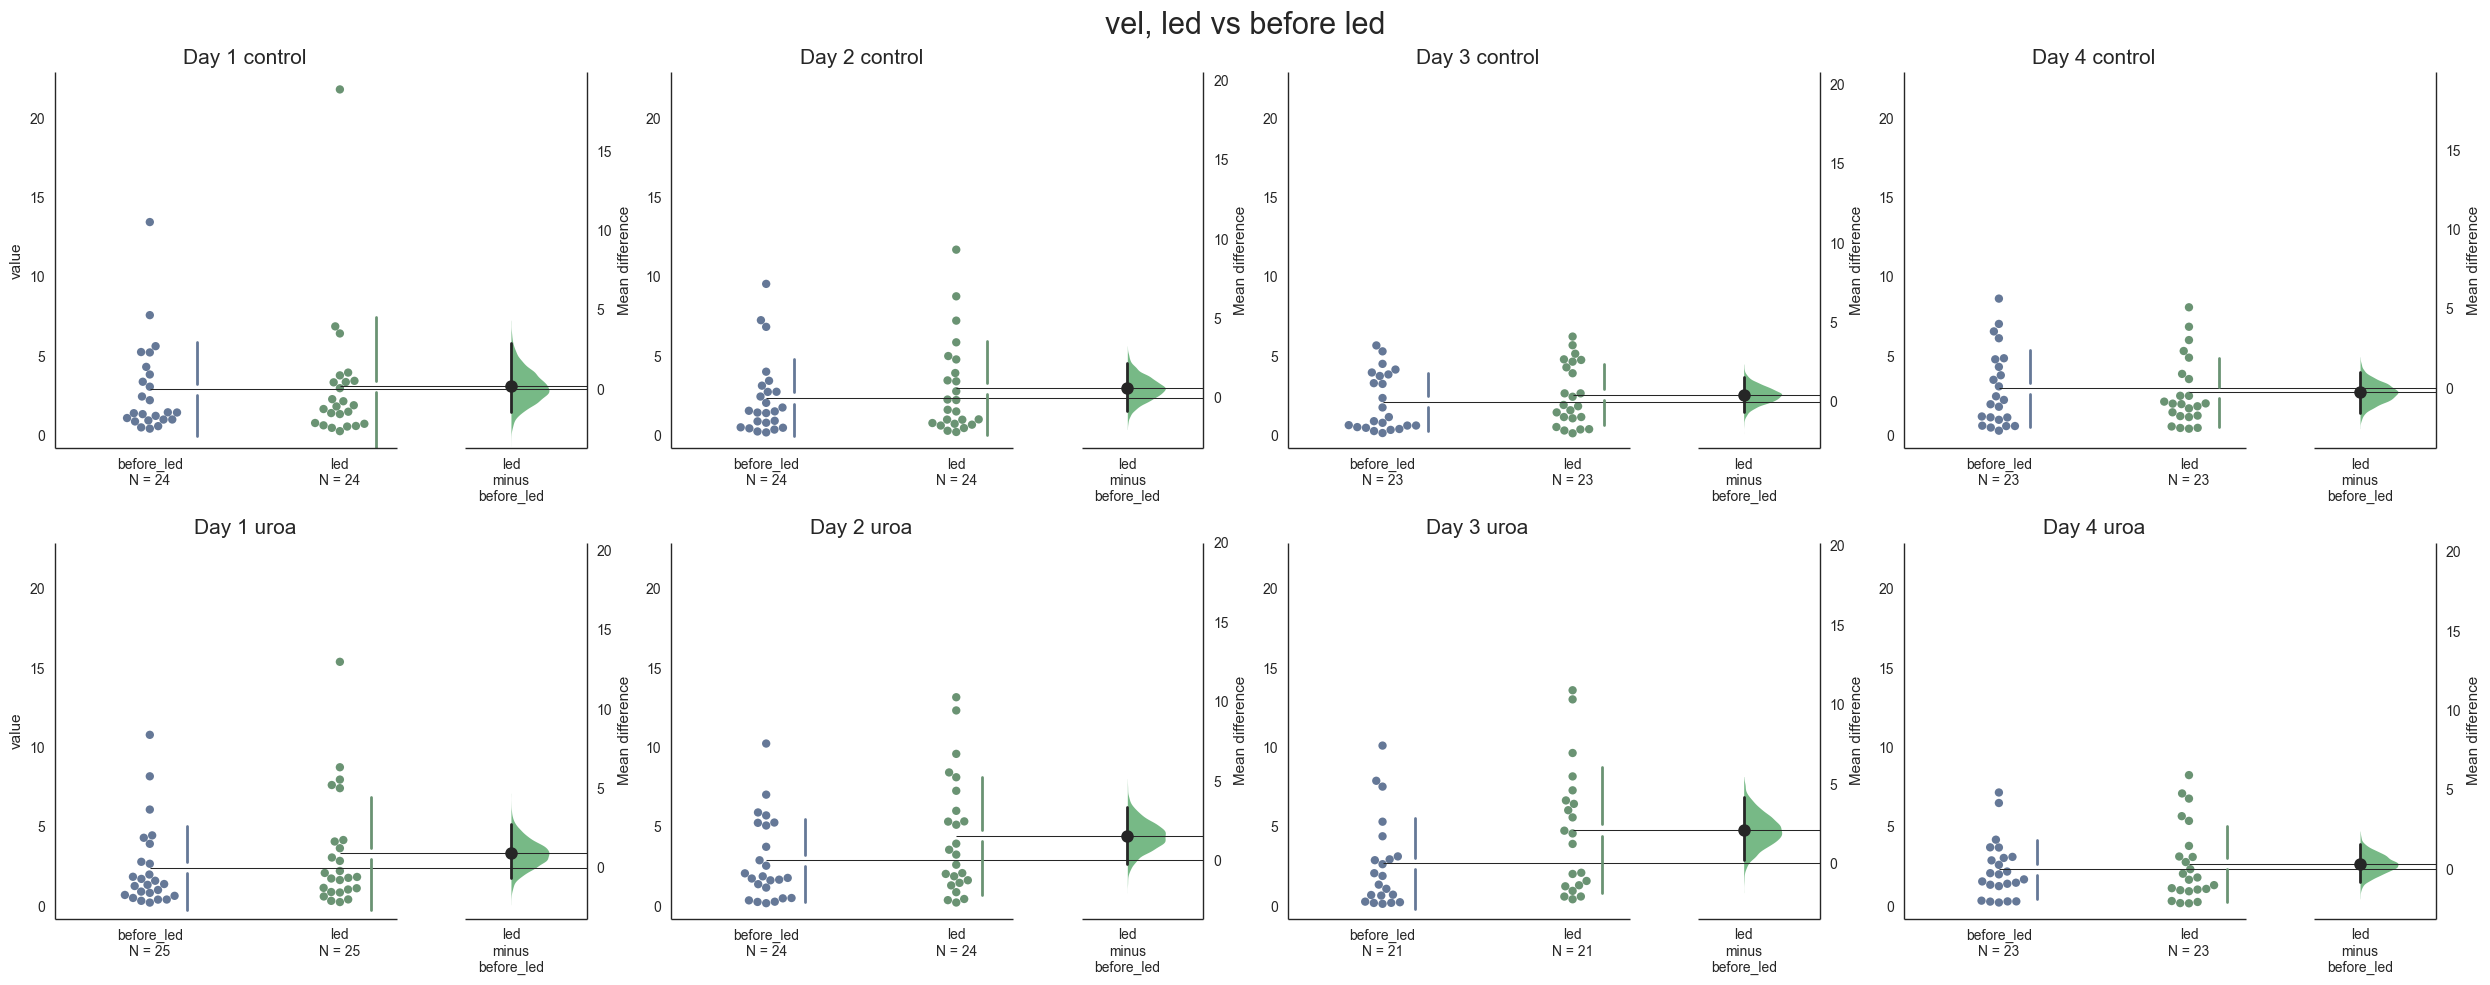

acc


<Figure size 800x550 with 0 Axes>

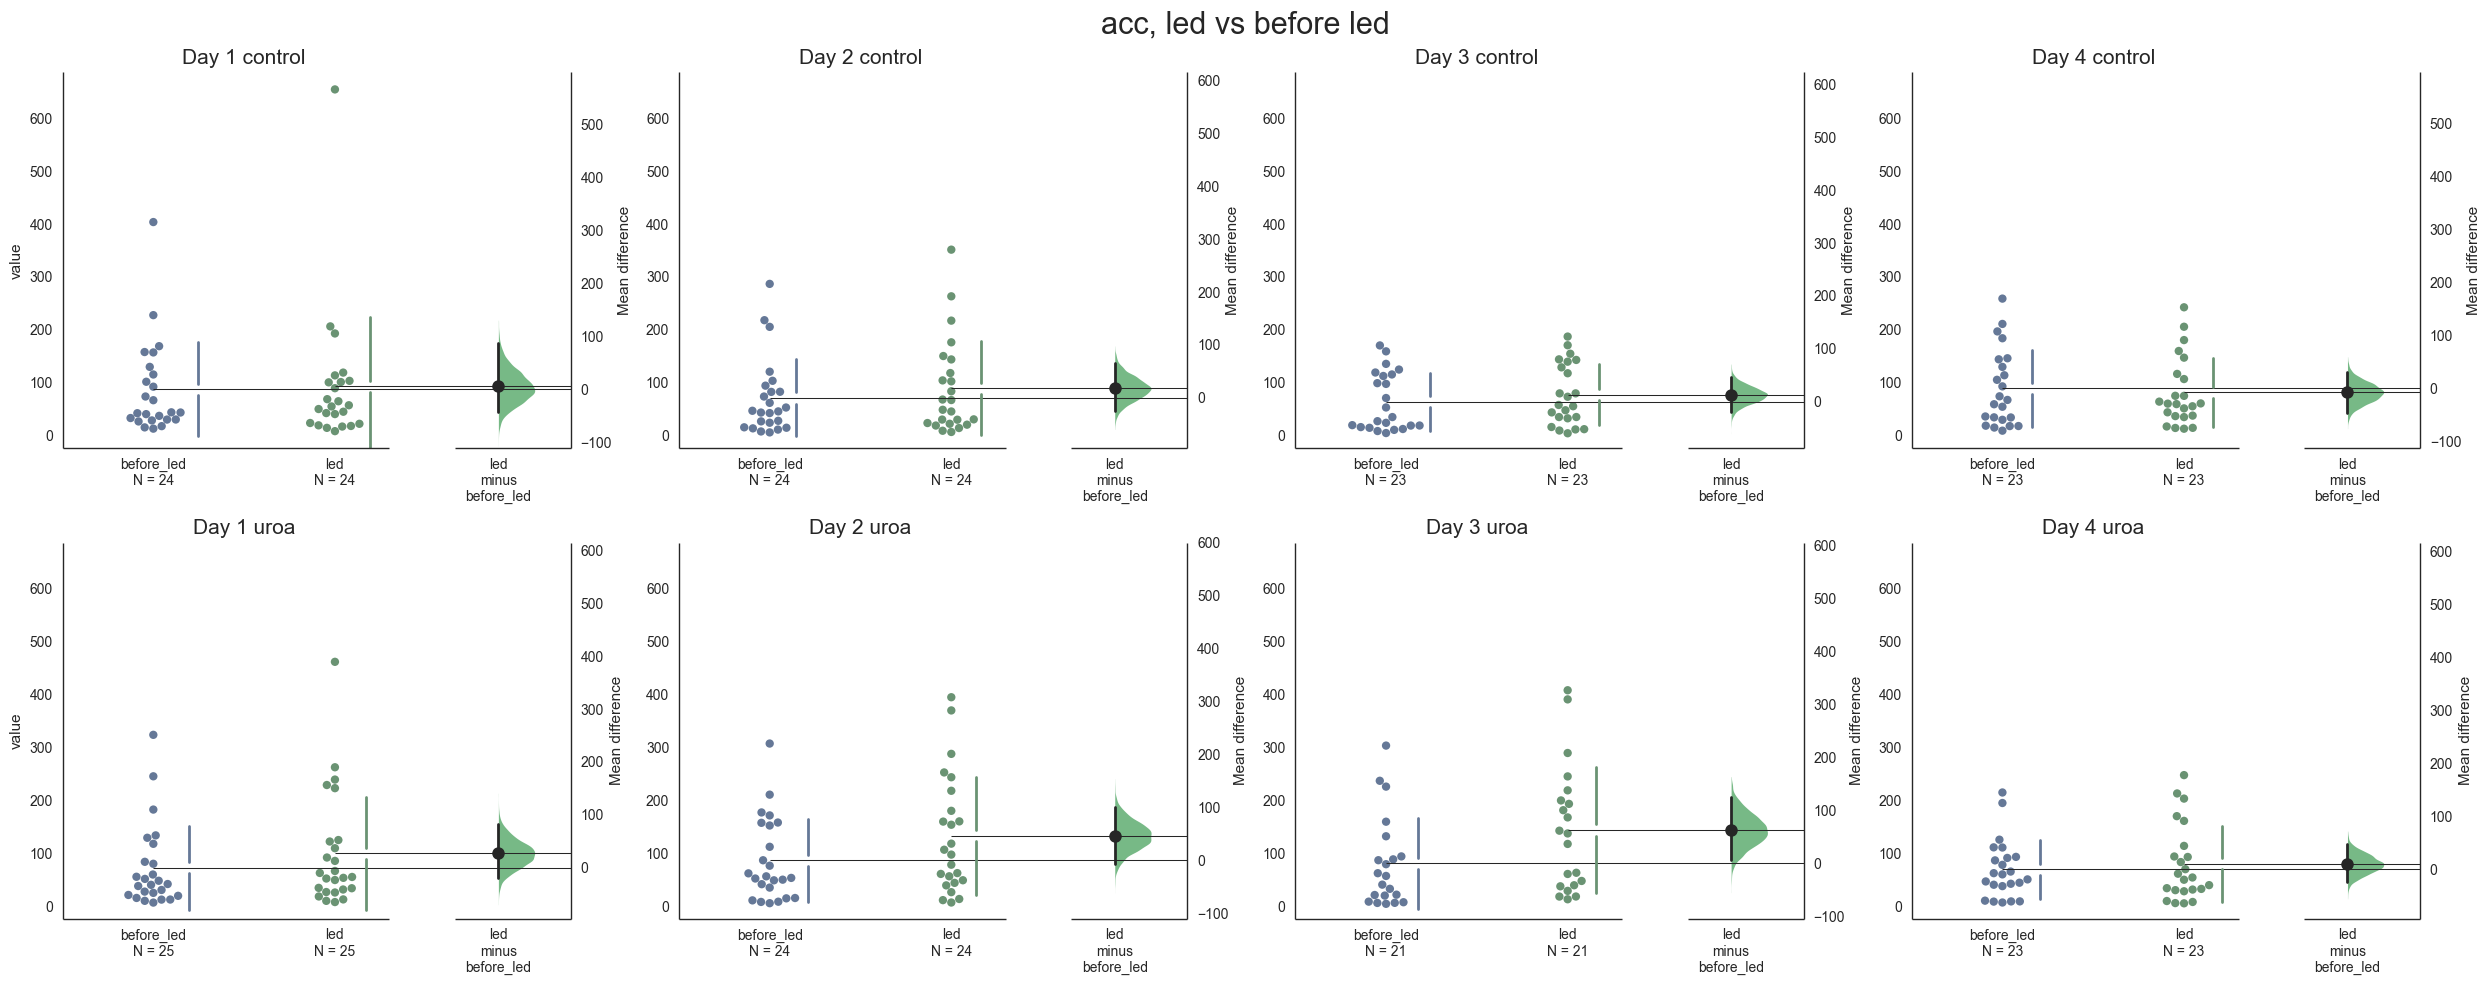

head_angle


<Figure size 800x550 with 0 Axes>

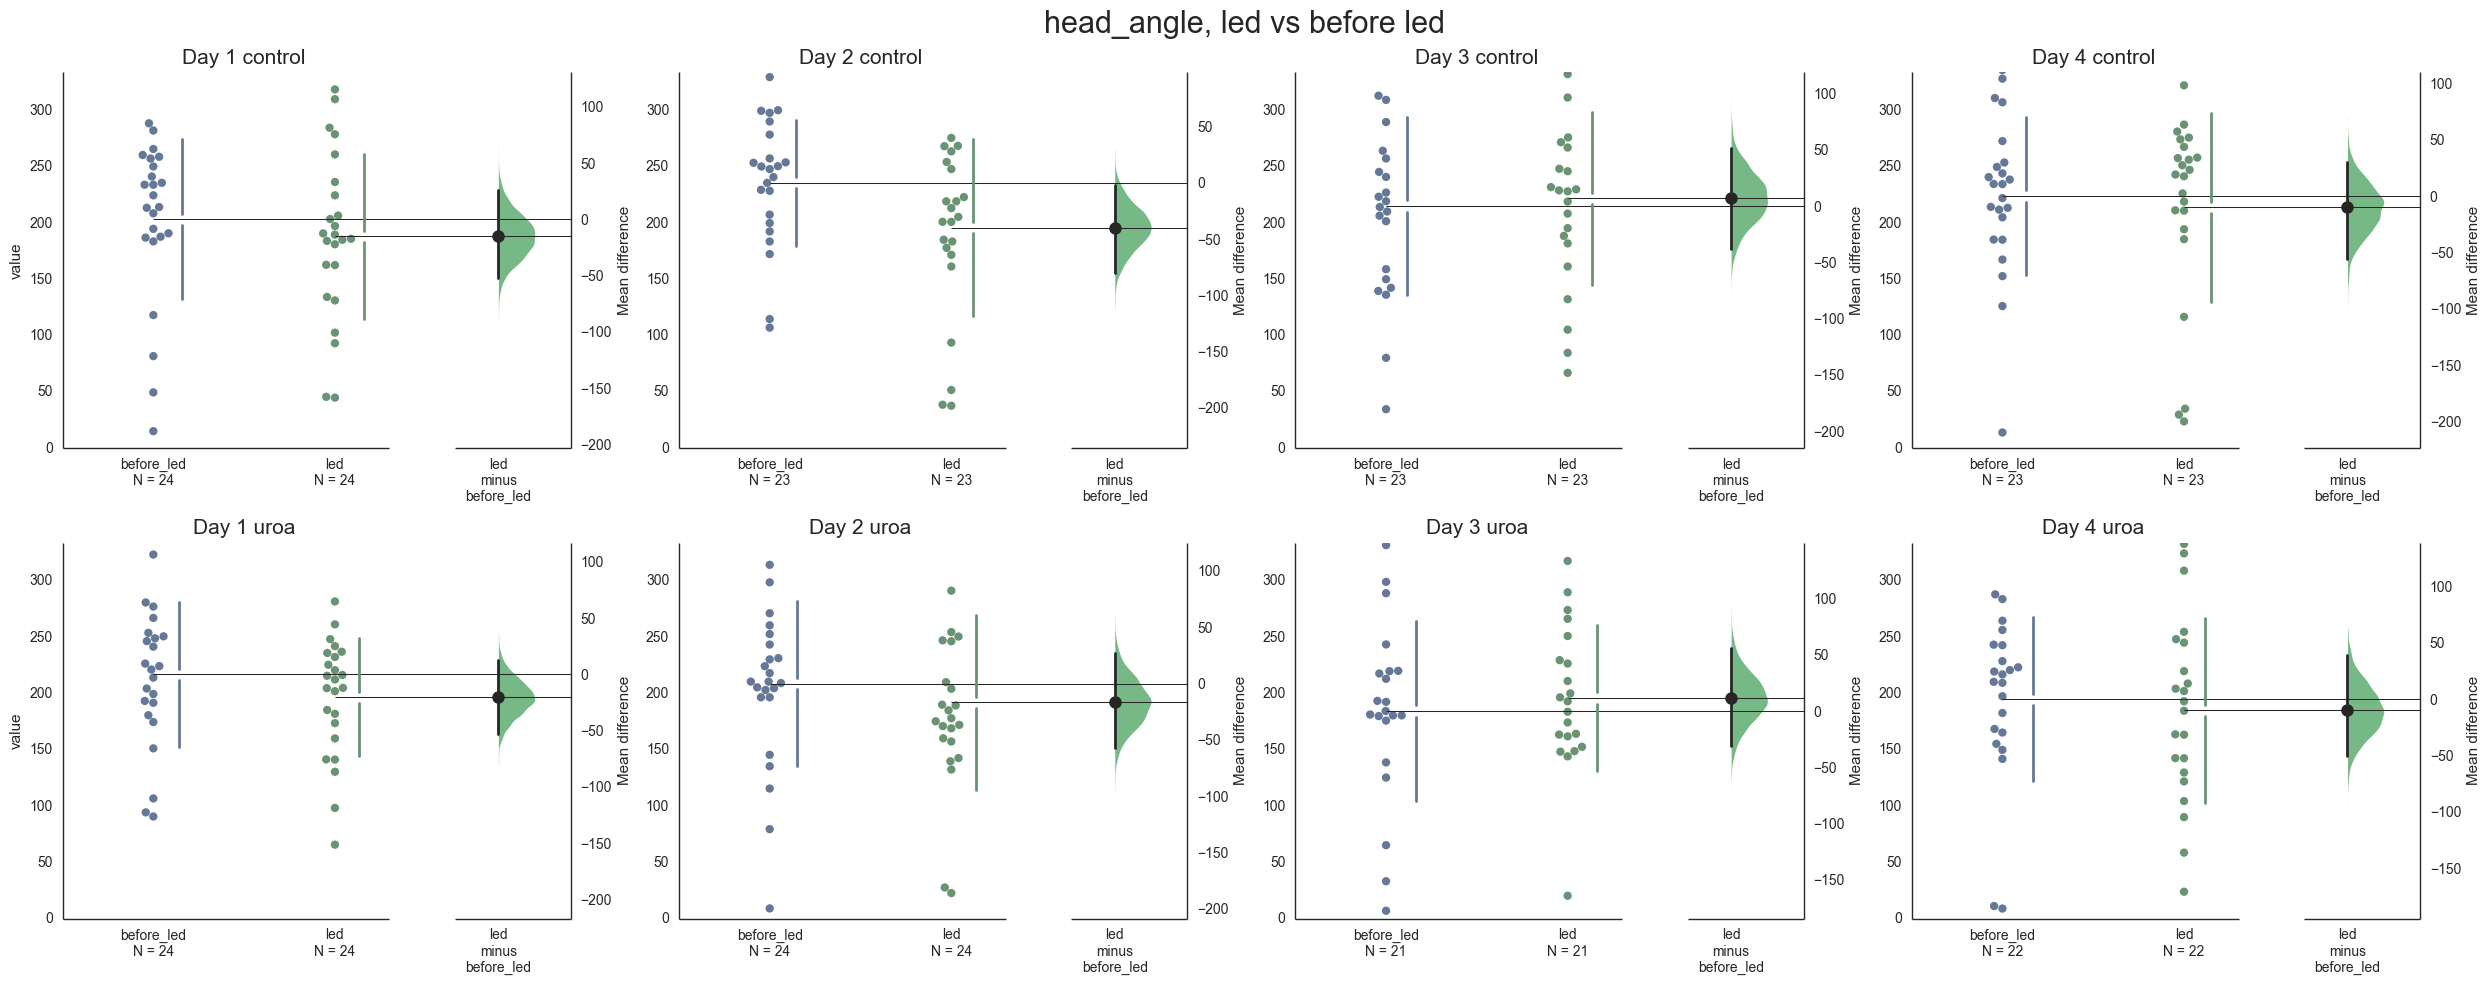

dist_surface


<Figure size 800x550 with 0 Axes>

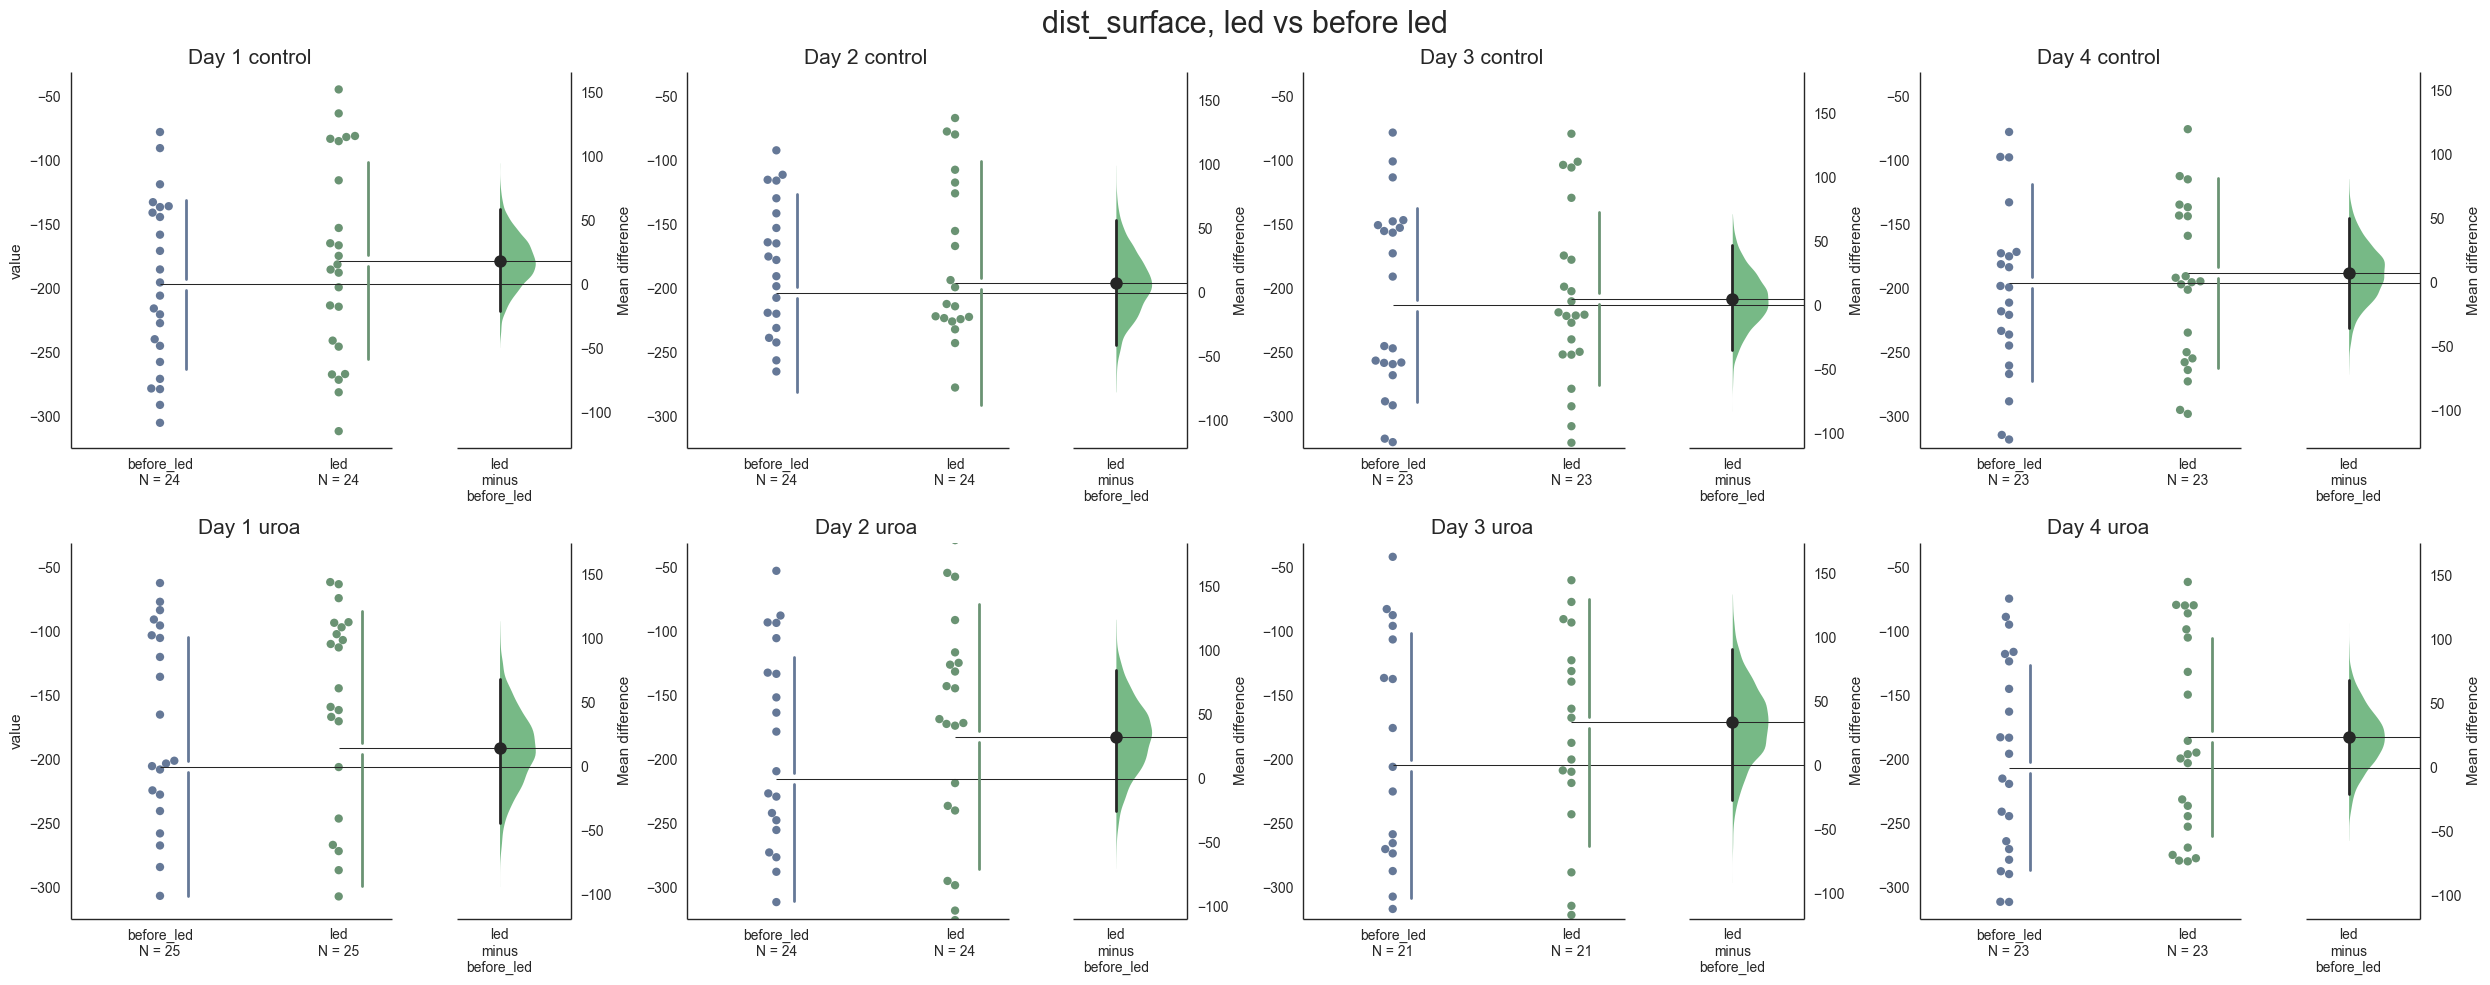

y_up


<Figure size 800x550 with 0 Axes>

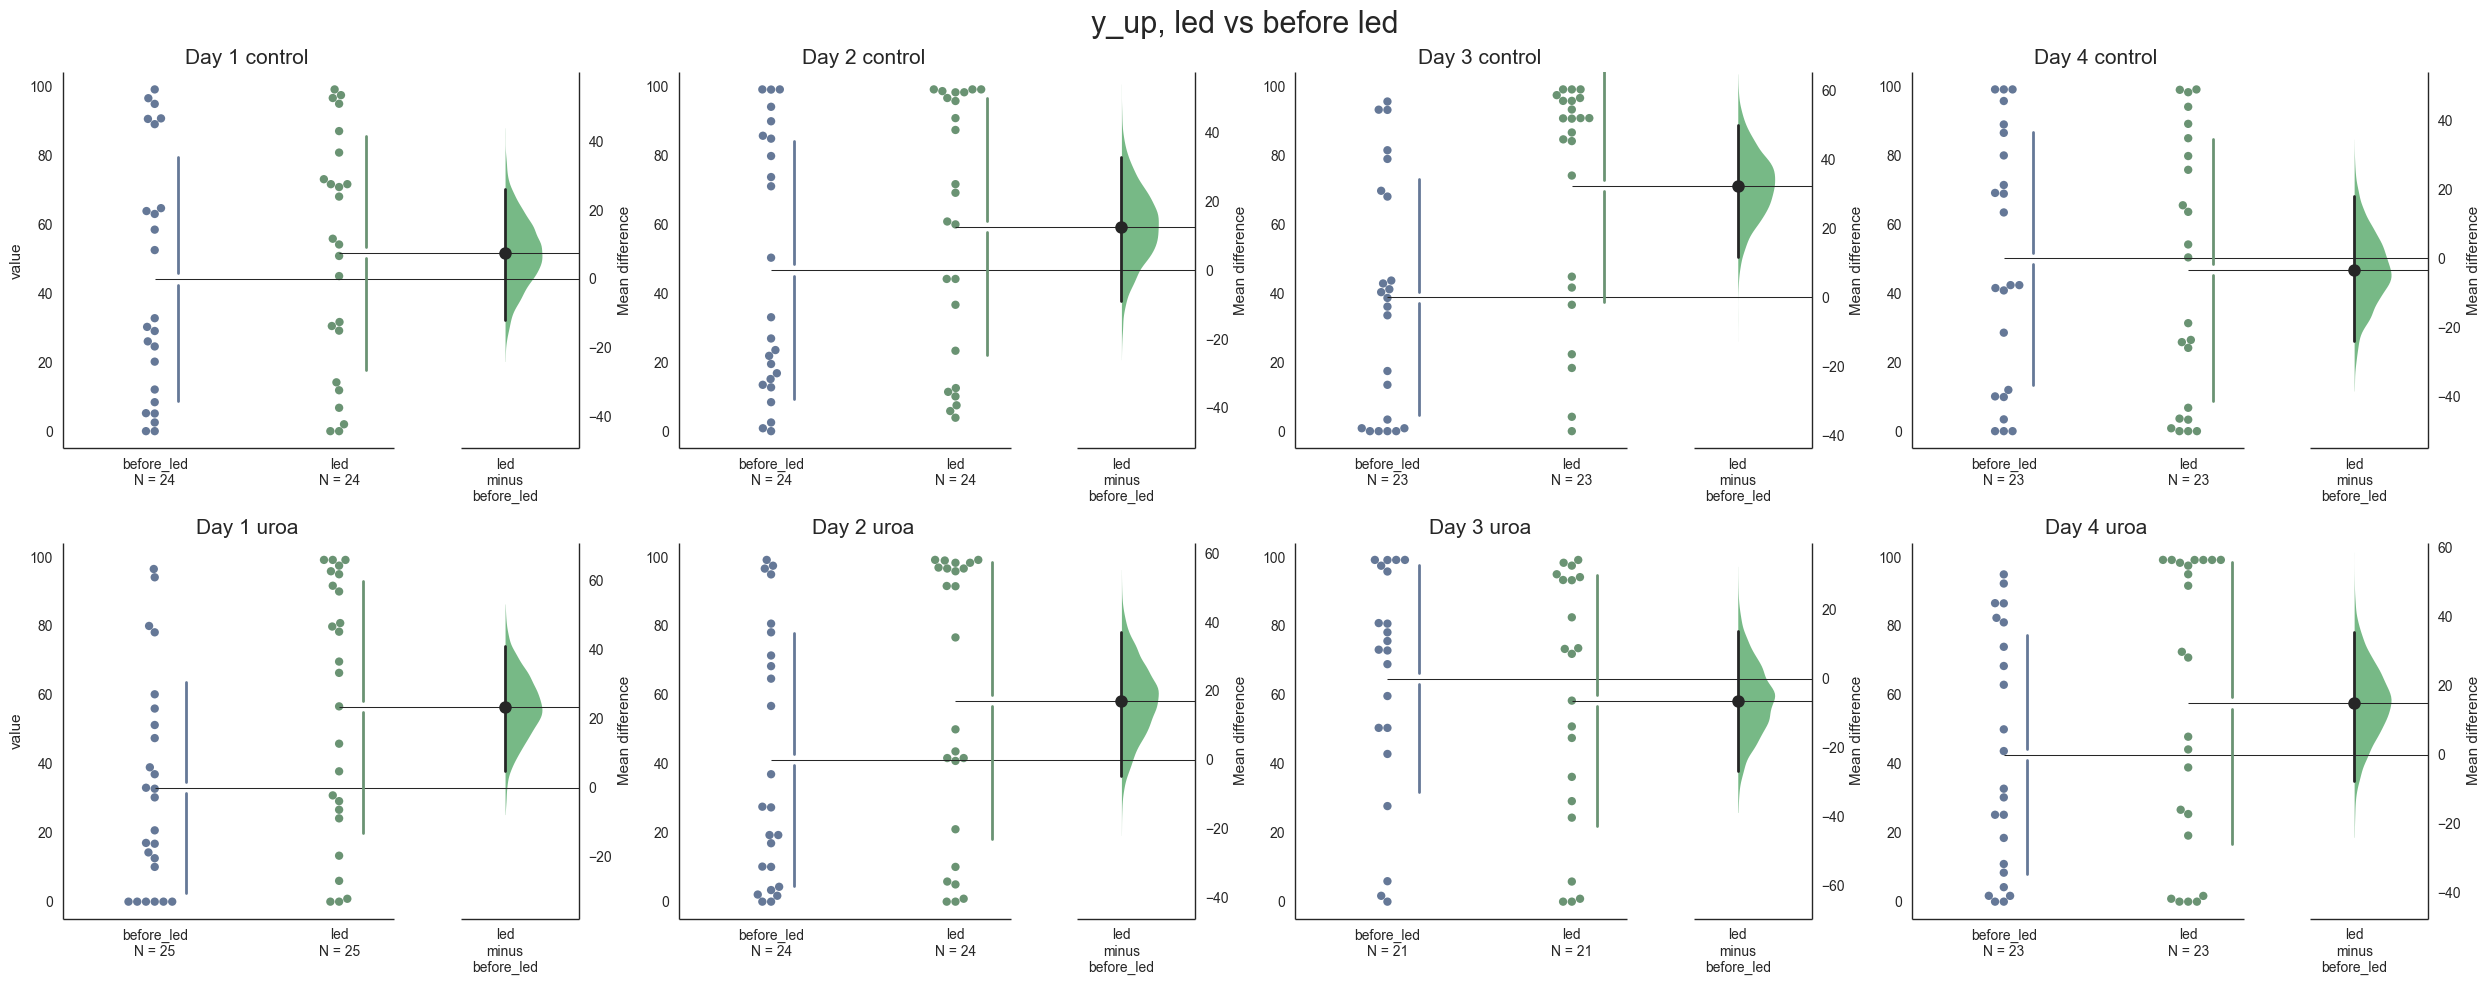

y_mag


<Figure size 800x550 with 0 Axes>

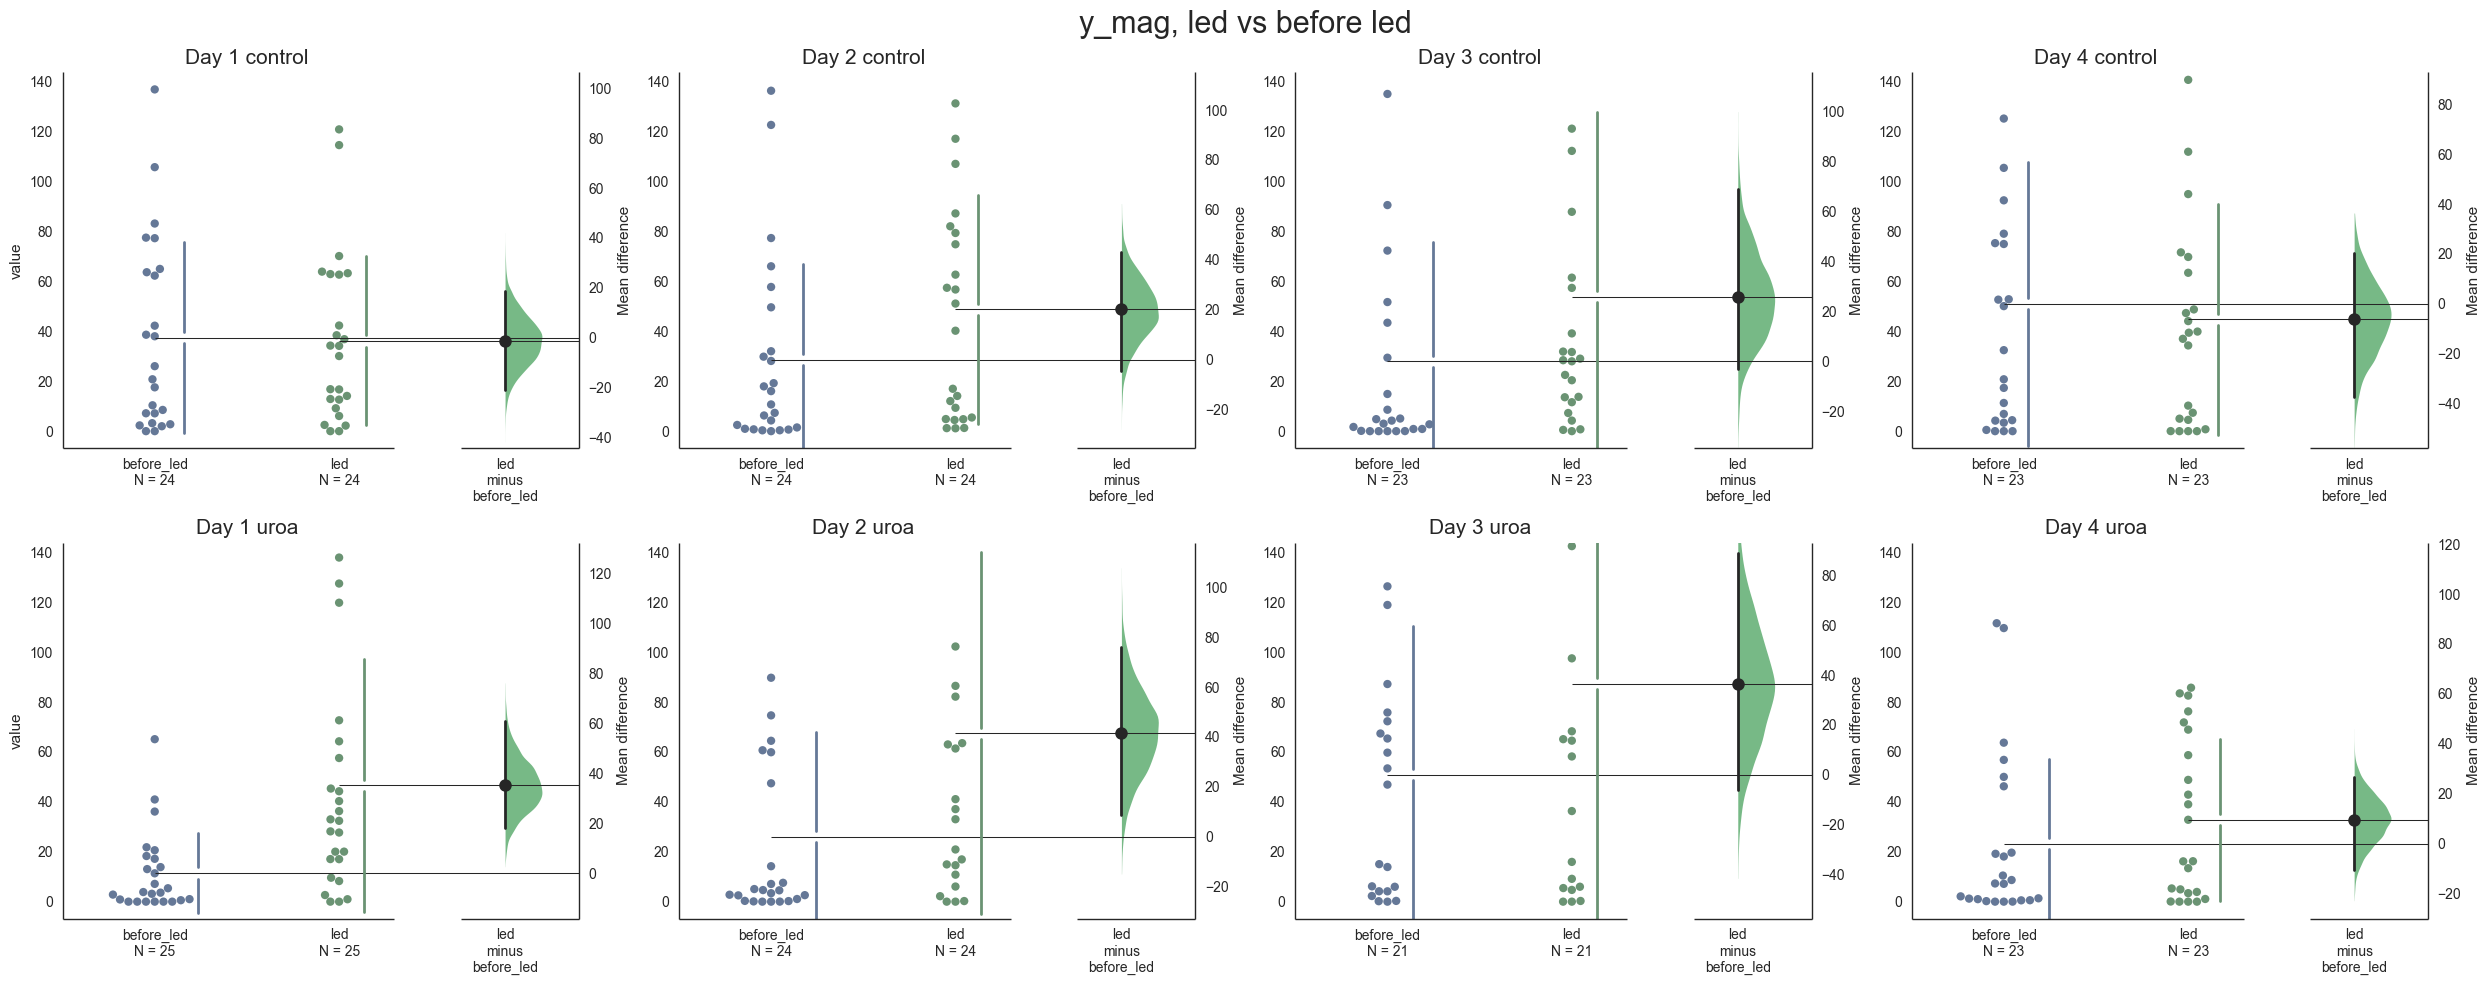

trajectory_angle


<Figure size 800x550 with 0 Axes>

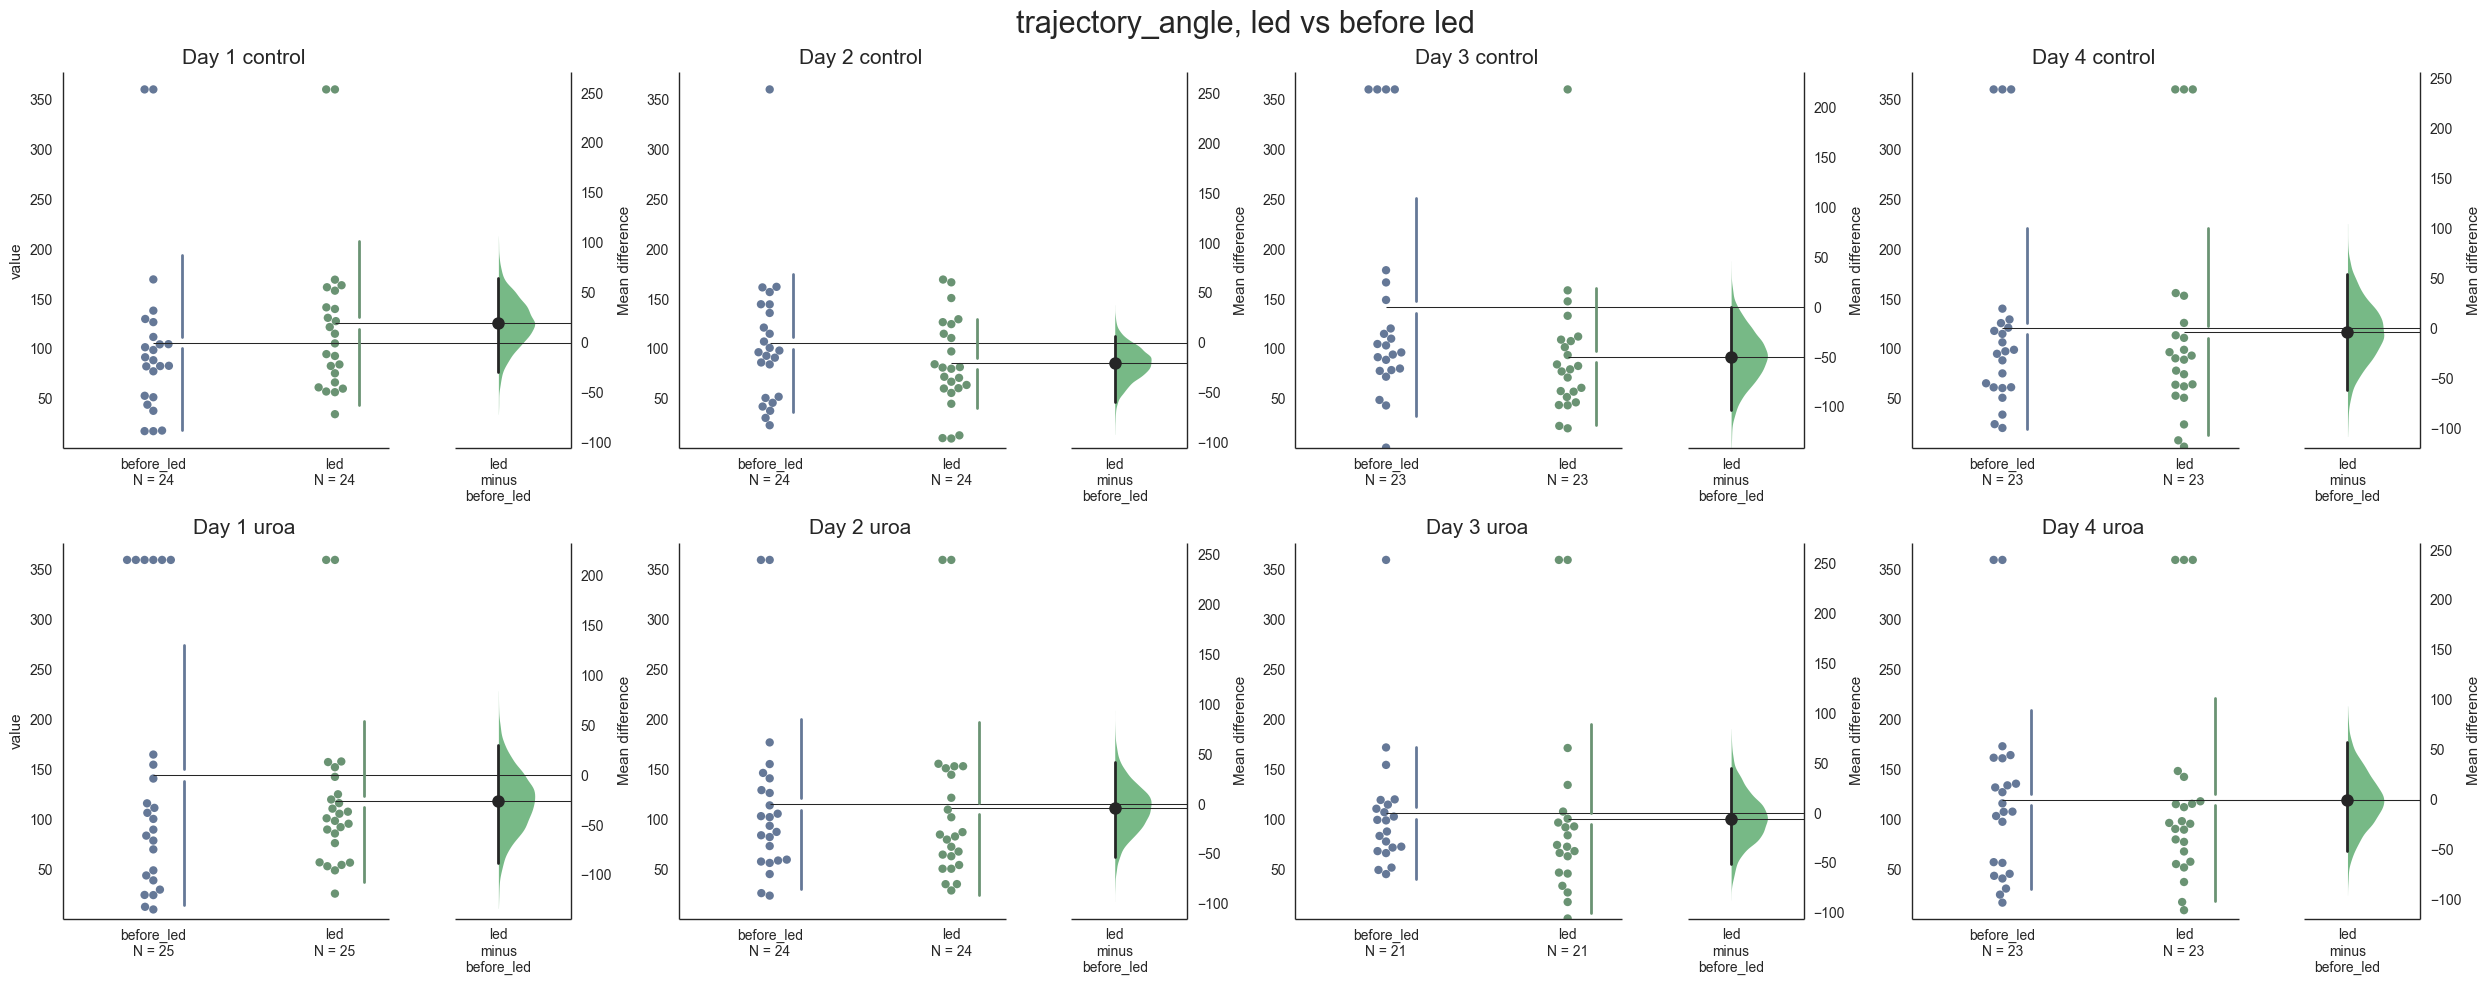

start_y_from_led


<Figure size 800x550 with 0 Axes>

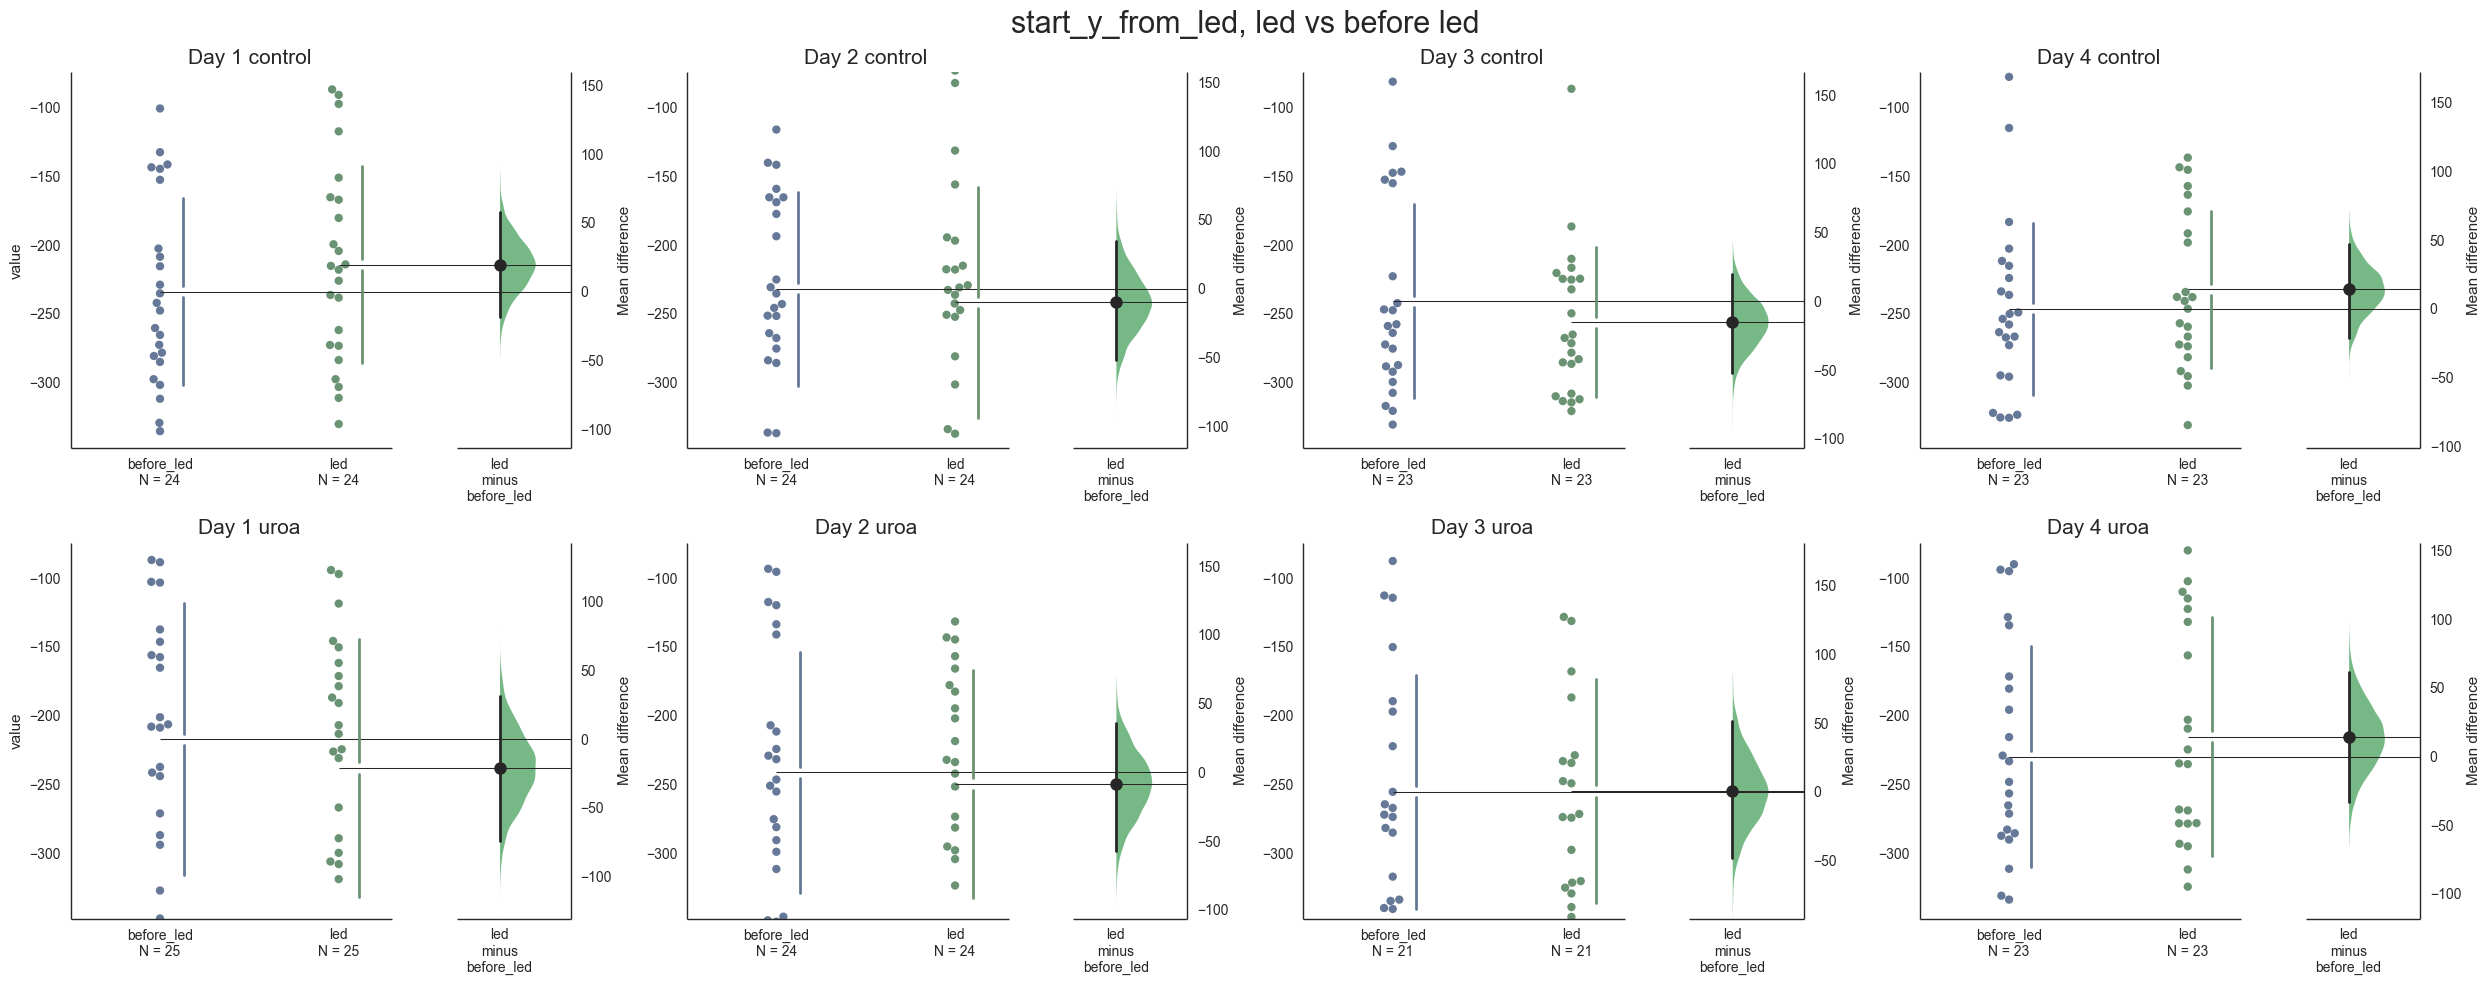

end_trajectory_angle


<Figure size 800x550 with 0 Axes>

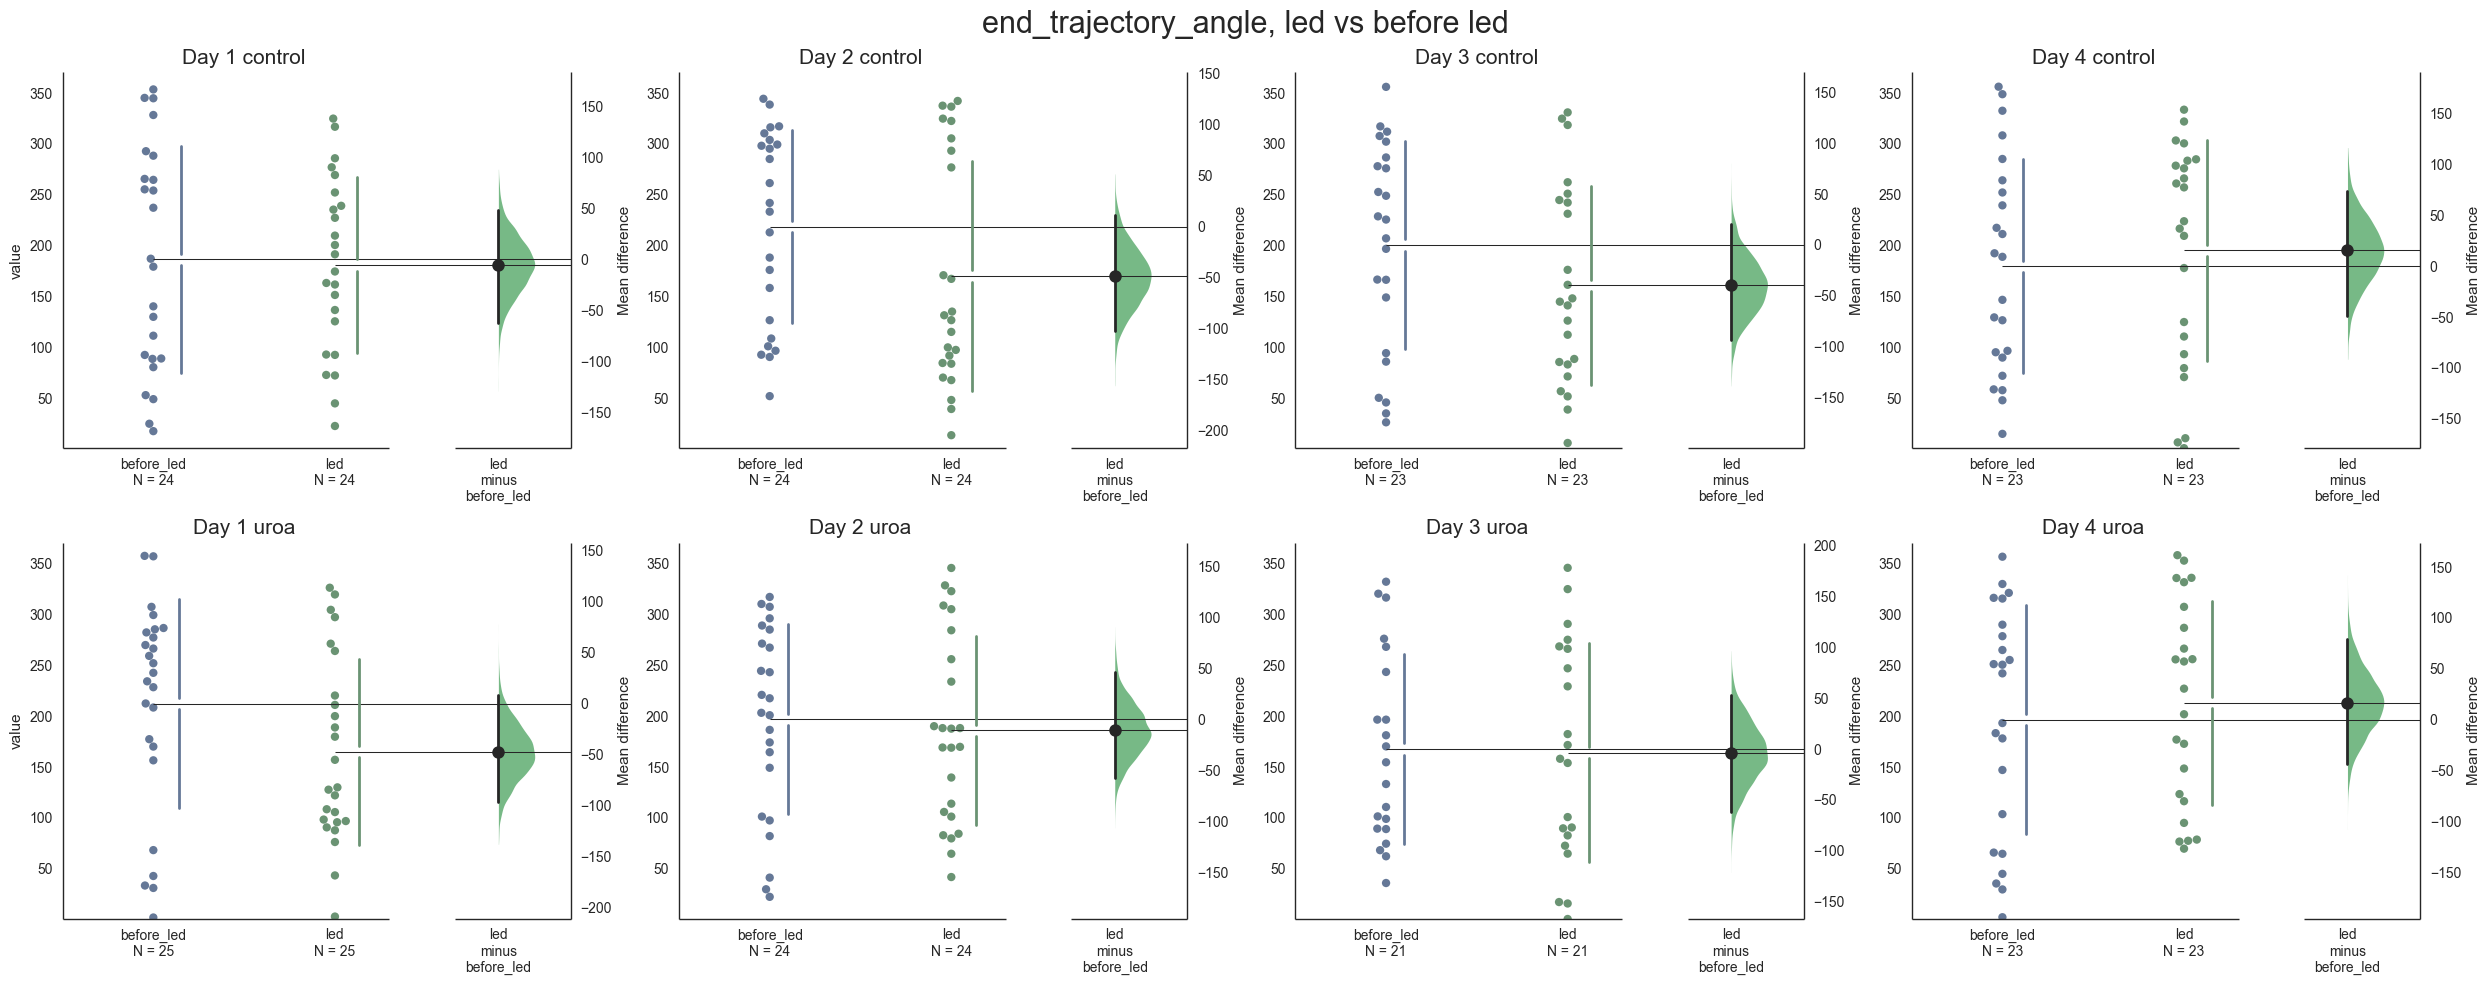

<Figure size 800x550 with 0 Axes>

In [23]:
for parameter in parameters:
    print(parameter)
    # box plot from the above data, all control in 1 plot, all uro in 1 plot, total 2 subplots
    led_parameter_df = led_df[["name", "uroa_control", "day", parameter]]
    before_led_parameter_df = before_led_df[["name","uroa_control", "day", parameter]]
    # merge led and before led dataframes on name, uroa_control and day
    parameter_df = pd.merge(led_parameter_df, before_led_parameter_df, on=['name', 'uroa_control', 'day'], suffixes=('', '_before_led'), how='inner')
    parameter_df = parameter_df.rename(columns={parameter: "led", f"{parameter}_before_led": "before_led"})
    # print(parameter_df.head())

    # save df
    parameter_df.to_csv(f"./data/visualisation/{EXPERIMENT_SET}/dabest_plots/{parameter}_led_vs_before_led.csv", index=False)
    
    # group by uroa_control and day and rename columns to led and before_led
    parameter_df = parameter_df.groupby(["uroa_control", "day"])
    
    # get keys for each group
    keys = parameter_df.groups.keys()
    # remove day 5 for uroa and control and return sorted keys
    keys = sorted([key for key in keys if key[1] != 5])

    fig, axes = plt.subplots(2, 4, figsize=(25,10), sharey=True)
    plt.suptitle(f"{parameter}, led vs before led", fontsize=22)
    #leave more space between subplots
    fig.subplots_adjust(hspace=0.7)
    for i, axes in enumerate(axes.flat):
        # get the group for each key
        group = parameter_df.get_group(keys[i])
        #drop na
        group = group.dropna()
        # create dabest object
        dabest_obj = dabest.load(group, idx=("before_led", "led"))#, paired= "baseline", id_col="name")
        # plot the dabest object
        dabest_obj.mean_diff.plot(ax=axes)
        # paired plot
        # make the layout of the plot tight
        plt.tight_layout()
        # set the title for the plot
        axes.set_title(f"Day {keys[i][1]} {'uroa' if keys[i][0] == 1 else 'control'}", fontsize=15)
    plt.show()
    # save png and svg
    plt.savefig(dabest_save_path+f"{parameter}_dabest.png")
    plt.savefig(dabest_save_path+f"{parameter}_dabest.svg")